# Explainable Multi-Entity Fraud Intelligence Framework

## JP Morgan Data Analytics Internship Project



### Objective
The objective of this project is to analyse banking transaction, customer, and merchant datasets in order to identify fraud patterns, generate explainable risk intelligence, and prioritize high-risk alerts efficiently.

This project focuses on understanding fraud behavior from multiple perspectives including transaction activity, customer behavior, and merchant risk ecosystems.

Fraud operations teams face increasing alert volumes, synthetic identity risks, and constrained investigation capacity. 

This project builds an explainable fraud-alert prioritisation framework designed to:
- identify suspicious transactions,
- prioritize investigator queues,
- improve operational efficiency,
- and provide explainable risk indicators for fraud analysts.

The solution combines:
- fraud risk modelling,
- behavioral analytics,
- operational dashboards,
- and investigator triage workflows.

# Importing Python Libraries

This step imports the required Python libraries used throughout the project.

- pandas → data manipulation and analysis
- numpy → numerical operations
- matplotlib → data visualization
- seaborn → statistical visualizations

These libraries form the foundation of data analytics workflows in Python.

In [109]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [110]:
import warnings

warnings.filterwarnings("ignore")

# Loading Datasets

This step loads the three core datasets used in the project:

1. Transactions Dataset
   - Contains transaction-level fraud activity and behavioral signals.

2. Customers Dataset
   - Contains customer-level demographic and behavioral information.

3. Merchants Dataset
   - Contains merchant-level transaction and risk information.

Loading all datasets enables multi-entity fraud analysis instead of isolated transaction-level analysis.

In [111]:
transactions = pd.read_csv('../B_Dataset/raw/transactions.csv')

customers = pd.read_csv('../B_Dataset/raw/customers.csv')

merchants = pd.read_csv('../B_Dataset/raw/merchants.csv')

## Project Assumptions and Scope

This analysis uses synthetic transaction, customer, and merchant data to simulate a fraud-alert prioritisation workflow for investigator triage.

The primary unit of analysis is one transaction. Each row in the final enriched dataset represents one transaction enriched with customer and merchant attributes.

The target variable is `fraud_label`.

This project should be interpreted as a prototype fraud operations framework rather than a production fraud control system. Model scores and risk tiers are designed to support analyst review and prioritisation, not automatic customer blocking.

Key assumptions:

- The datasets are synthetic and used for analytical simulation.
- Fraud investigation outcomes are simplified into a binary `fraud_label`.
- Customer risk bands and synthetic identity indicators are simplified representations.
- Real-time latency, payment authorisation rules, and live case management systems are outside the project scope.
- Model outputs are treated as decision-support signals for investigators.
- Human review remains required for high-risk fraud decisions.

## Data Lineage and Audit Checks

To make the analysis reproducible and audit-ready, the raw datasets are validated before modelling and dashboard preparation.

This section confirms:

- Which raw datasets are used
- The join keys used to enrich transaction-level data
- Row counts before and after joins
- Duplicate checks
- Missing target checks
- Fraud rate consistency
- Final modelling grain

The modelling grain is:

**One row = one transaction**

The target variable is:

**`fraud_label`**

The operational alert indicator is:

**`alert_generated`**, used for operational monitoring and dashboard analysis where relevant, but excluded from model training to reduce leakage risk.

In [112]:
# Data lineage and audit checks

lineage_summary = pd.DataFrame({
    "Dataset": ["transactions.csv", "customers.csv", "merchants.csv"],
    "Original Rows": [len(transactions), len(customers), len(merchants)],
    "Join Key": [
        "transaction_id / customer_id / merchant_id",
        "customer_id",
        "merchant_id"
    ],
    "Primary Use": [
        "Transaction-level modelling and fraud target",
        "Customer enrichment: segment, KYC and synthetic identity attributes",
        "Merchant enrichment: merchant category and merchant risk attributes"
    ],
    "Duplicate Check": [
        transactions["transaction_id"].duplicated().sum(),
        customers["customer_id"].duplicated().sum(),
        merchants["merchant_id"].duplicated().sum()
    ],
    "Missing Target Check": [
        transactions["fraud_label"].isna().sum(),
        "Not applicable",
        "Not applicable"
    ]
})

lineage_summary

,Dataset,Original Rows,Join Key,Primary Use,Duplicate Check,Missing Target Check
0,transactions.csv,5000,transaction_id / customer_id / merchant_id,Transaction-level modelling and fraud target,0,0
1,customers.csv,5000,customer_id,"Customer enrichment: segment, KYC and syntheti...",0,Not applicable
2,merchants.csv,5000,merchant_id,Merchant enrichment: merchant category and mer...,0,Not applicable


## Dataset Summary Table

This table summarises the core dataset characteristics used for transaction-level fraud modelling and dashboard reporting.


In [113]:
# Dataset summary table for report and appendix

dataset_summary = pd.DataFrame({
    "Metric": [
        "Transaction Records",
        "Customer Records",
        "Merchant Records",
        "Fraud Cases",
        "Legitimate Transactions",
        "Fraud Rate (%)",
        "Modelling Grain",
        "Target Variable"
    ],
    "Value": [
        len(transactions),
        len(customers),
        len(merchants),
        int(transactions["fraud_label"].sum()),
        int((transactions["fraud_label"] == 0).sum()),
        round(transactions["fraud_label"].mean() * 100, 2),
        "One transaction per row",
        "fraud_label"
    ]
})

dataset_summary

,Metric,Value
0,Transaction Records,5000
1,Customer Records,5000
2,Merchant Records,5000
3,Fraud Cases,201
4,Legitimate Transactions,4799
5,Fraud Rate (%),4.02
6,Modelling Grain,One transaction per row
7,Target Variable,fraud_label


In [114]:
# Core sanity checks for transaction-level modelling

sanity_checks = {
    "Transaction rows": len(transactions),
    "Unique transaction IDs": transactions["transaction_id"].nunique(),
    "Duplicate transaction IDs": transactions["transaction_id"].duplicated().sum(),
    "Missing fraud_label values": transactions["fraud_label"].isna().sum(),
    "Fraud cases": int(transactions["fraud_label"].sum()),
    "Fraud rate (%)": round(transactions["fraud_label"].mean() * 100, 2)
}

sanity_checks

{'Transaction rows': 5000,
 'Unique transaction IDs': 5000,
 'Duplicate transaction IDs': np.int64(0),
 'Missing fraud_label values': np.int64(0),
 'Fraud cases': 201,
 'Fraud rate (%)': np.float64(4.02)}

In [115]:
# Join validation checks before creating the enriched modelling dataset

transactions_before_join = len(transactions)

merged_audit = transactions.merge(
    customers,
    on="customer_id",
    how="left",
    indicator="customer_join_status"
)

merged_audit = merged_audit.merge(
    merchants,
    on="merchant_id",
    how="left",
    indicator="merchant_join_status"
)

join_validation_summary = pd.DataFrame({
    "Check": [
        "Transaction rows before joins",
        "Transaction rows after joins",
        "Rows preserved after enrichment",
        "Unique transaction IDs after joins",
        "Customer records matched",
        "Customer records not matched",
        "Merchant records matched",
        "Merchant records not matched",
        "Fraud rate after joins (%)"
    ],
    "Value": [
        transactions_before_join,
        len(merged_audit),
        len(merged_audit) == transactions_before_join,
        merged_audit["transaction_id"].nunique(),
        (merged_audit["customer_join_status"] == "both").sum(),
        (merged_audit["customer_join_status"] == "left_only").sum(),
        (merged_audit["merchant_join_status"] == "both").sum(),
        (merged_audit["merchant_join_status"] == "left_only").sum(),
        round(merged_audit["fraud_label"].mean() * 100, 2)
    ]
})

join_validation_summary

,Check,Value
0,Transaction rows before joins,5000
1,Transaction rows after joins,5000
2,Rows preserved after enrichment,True
3,Unique transaction IDs after joins,5000
4,Customer records matched,4178
5,Customer records not matched,822
6,Merchant records matched,5000
7,Merchant records not matched,0
8,Fraud rate after joins (%),4.02


### Data Lineage Interpretation

The join validation confirms that all 5,000 transaction rows were preserved after enriching the transaction data with customer and merchant attributes.

No duplicate transaction records were created during the enrichment process, and the fraud rate remained stable at 4.02% after the joins. This confirms that the modelling and dashboard dataset preserves the correct transaction-level grain.

Customer enrichment matched 4,178 transactions, while 822 transactions did not have matching customer records. These unmatched customer attributes are retained as missing values and handled during preprocessing to avoid dropping valid transaction records.

Merchant enrichment matched all 5,000 transactions, confirming full merchant coverage in the enriched dataset.

## Fraud Feature Rationale

Fraud feature engineering should not only create variables for modelling; each feature should have a clear fraud hypothesis and operational use.

The table below explains the key fraud-relevant features used in the analysis, why they matter, the expected risk direction, and how they support investigator triage or dashboard interpretation.

In [116]:
# Fraud feature rationale table

feature_rationale = pd.DataFrame({
    "Feature": [
        "device_risk_score",
        "merchant_risk_score",
        "new_device_flag",
        "is_night_flag",
        "velocity_1h",
        "velocity_24h",
        "geo_distance_km",
        "channel",
        "merchant_category",
        "kyc_risk_band",
        "synthetic_identity_score"
    ],
    "Fraud Rationale": [
        "Higher device risk may indicate suspicious device behaviour or possible account compromise.",
        "Higher merchant risk may indicate merchants with greater exposure to fraudulent activity.",
        "A new or unfamiliar device may indicate account takeover or unauthorised access.",
        "Night-time transactions may occur outside normal customer behaviour patterns.",
        "High short-term transaction velocity may indicate rapid fraud attempts.",
        "High 24-hour transaction velocity may indicate repeated suspicious activity.",
        "Large geographic distance may indicate unusual location behaviour or possible geo anomaly.",
        "Certain channels, such as P2P or Wire, may carry higher fraud exposure.",
        "Some merchant categories may show higher fraud concentration.",
        "Higher KYC risk bands may indicate weaker customer risk profile or onboarding concerns.",
        "Higher synthetic identity score may indicate potential identity manipulation risk."
    ],
    "Expected Risk Direction": [
        "Higher score → higher risk",
        "Higher score → higher risk",
        "New device → higher risk",
        "Night transaction → higher risk",
        "Higher velocity → higher risk",
        "Higher velocity → higher risk",
        "Higher distance → higher risk",
        "P2P/Wire → higher risk",
        "High-risk categories → higher risk",
        "Higher KYC risk → higher risk",
        "Higher score → higher risk"
    ],
    "Operational Use": [
        "Reason code and model input",
        "Reason code and merchant monitoring",
        "Reason code for investigator review",
        "Reason code and dashboard segmentation",
        "Velocity alert and reason code",
        "Velocity monitoring and queue prioritisation",
        "Geo anomaly reason code",
        "Channel risk monitoring and prioritisation",
        "Merchant category risk monitoring",
        "Customer risk segmentation",
        "Synthetic identity risk monitoring"
    ]
})

feature_rationale

,Feature,Fraud Rationale,Expected Risk Direction,Operational Use
0,device_risk_score,Higher device risk may indicate suspicious dev...,Higher score → higher risk,Reason code and model input
1,merchant_risk_score,Higher merchant risk may indicate merchants wi...,Higher score → higher risk,Reason code and merchant monitoring
2,new_device_flag,A new or unfamiliar device may indicate accoun...,New device → higher risk,Reason code for investigator review
3,is_night_flag,Night-time transactions may occur outside norm...,Night transaction → higher risk,Reason code and dashboard segmentation
4,velocity_1h,High short-term transaction velocity may indic...,Higher velocity → higher risk,Velocity alert and reason code
5,velocity_24h,High 24-hour transaction velocity may indicate...,Higher velocity → higher risk,Velocity monitoring and queue prioritisation
6,geo_distance_km,Large geographic distance may indicate unusual...,Higher distance → higher risk,Geo anomaly reason code
7,channel,"Certain channels, such as P2P or Wire, may car...",P2P/Wire → higher risk,Channel risk monitoring and prioritisation
8,merchant_category,Some merchant categories may show higher fraud...,High-risk categories → higher risk,Merchant category risk monitoring
9,kyc_risk_band,Higher KYC risk bands may indicate weaker cust...,Higher KYC risk → higher risk,Customer risk segmentation


# Inspecting Dataset Dimensions

This step checks the number of rows and columns in each dataset.

Understanding dataset size helps evaluate:
- data scale,
- analytical complexity,
- processing requirements,
- and coverage of fraud activity.

In [117]:
print("Transactions Shape:", transactions.shape)

print("Customers Shape:", customers.shape)

print("Merchants Shape:", merchants.shape)

Transactions Shape: (5000, 17)
Customers Shape: (5000, 8)
Merchants Shape: (5000, 4)


## Operational Fraud Risk Logic

This project focuses on building an explainable fraud-alert prioritisation framework for investigator operations.

Transactions are operationally categorized into:
- High Risk → immediate escalation,
- Medium Risk → analyst review,
- Low Risk → ongoing monitoring.

The prioritisation strategy incorporates behavioral and operational fraud indicators such as:
- device familiarity,
- transaction timing,
- merchant concentration,
- customer risk segmentation,
- synthetic identity indicators,
- and transaction channel exposure.

The objective is not only to detect fraud, but also to improve investigator efficiency, reduce false positives, and support explainable operational decision-making.

In [118]:
df = transactions \
    .merge(customers, on="customer_id", how="left") \
    .merge(merchants, on="merchant_id", how="left")

In [119]:
transactions.columns

Index(['transaction_id', 'event_ts', 'customer_id', 'merchant_id', 'channel',
       'transaction_amount_usd', 'txn_country', 'txn_hour',
       'device_risk_score', 'new_device_flag', 'velocity_1h', 'velocity_24h',
       'geo_distance_km', 'merchant_risk_score', 'is_night_flag',
       'alert_generated', 'fraud_label'],
      dtype='str')

In [120]:
df["event_ts"] = pd.to_datetime(df["event_ts"])

In [121]:
df["hour"] = df["event_ts"].dt.hour
df["dayofweek"] = df["event_ts"].dt.dayofweek
df["is_weekend"] = df["dayofweek"] >= 5

In [122]:
[col for col in df.columns if "risk" in col.lower()]

['device_risk_score',
 'merchant_risk_score_x',
 'kyc_risk_band',
 'merchant_risk_score_y']

In [123]:
df["merchant_risk_score"] = df[["merchant_risk_score_x", "merchant_risk_score_y"]].mean(axis=1)
df.drop(columns=["merchant_risk_score_x", "merchant_risk_score_y"], inplace=True)

In [124]:
df["kyc_risk_band"].value_counts()

kyc_risk_band
Low       2669
Medium    1179
High       330
Name: count, dtype: int64

In [125]:
df = pd.get_dummies(df, columns=["kyc_risk_band"], drop_first=True)

In [126]:
df["total_risk_score"] = (
    df["device_risk_score"] +
    df["merchant_risk_score"]
)

In [127]:
[col for col in df.columns if "risk" in col.lower()]

['device_risk_score',
 'merchant_risk_score',
 'kyc_risk_band_Low',
 'kyc_risk_band_Medium',
 'total_risk_score']

In [128]:
df.columns.tolist()

['transaction_id',
 'event_ts',
 'customer_id',
 'merchant_id',
 'channel',
 'transaction_amount_usd',
 'txn_country',
 'txn_hour',
 'device_risk_score',
 'new_device_flag',
 'velocity_1h',
 'velocity_24h',
 'geo_distance_km',
 'is_night_flag',
 'alert_generated',
 'fraud_label',
 'age',
 'tenure_months',
 'segment',
 'home_country',
 'digital_only',
 'synthetic_identity_score',
 'merchant_category',
 'channel_default',
 'hour',
 'dayofweek',
 'is_weekend',
 'merchant_risk_score',
 'kyc_risk_band_Low',
 'kyc_risk_band_Medium',
 'total_risk_score']

In [129]:
risk_cols = [c for c in df.columns if "risk" in c.lower()]
risk_cols

['device_risk_score',
 'merchant_risk_score',
 'kyc_risk_band_Low',
 'kyc_risk_band_Medium',
 'total_risk_score']

In [130]:
df["total_risk_score"] = df[risk_cols].mean(axis=1)

In [131]:
"merchant_risk_score" in df.columns

True

In [132]:
df[["device_risk_score", "merchant_risk_score"]].head()

,device_risk_score,merchant_risk_score
0,0.747,0.5140
1,0.197,0.1900
2,0.393,0.5405
3,0.125,0.4735
4,0.138,0.0880


In [133]:
df["total_risk_score"] = (
    df["device_risk_score"] +
    df["merchant_risk_score"]
)

In [134]:
df["risk_gap"] = abs(df["device_risk_score"] - df["merchant_risk_score"])

In [135]:
df["fraud_label"].value_counts(normalize=True)

fraud_label
0    0.9598
1    0.0402
Name: proportion, dtype: float64

In [136]:
df.groupby("alert_generated")["fraud_label"].mean()

alert_generated
0    0.032716
1    0.300000
Name: fraud_label, dtype: float64

In [137]:
import sklearn
print(sklearn.__version__)

1.8.0


## Machine Learning Modelling Approach

This section evaluates supervised fraud detection models using transaction-level features enriched with customer and merchant attributes.

The modelling workflow includes:

- feature and target selection,
- categorical encoding,
- train-test splitting with stratification,
- baseline Logistic Regression modelling,
- XGBoost comparison,
- threshold evaluation,
- and operational KPI interpretation.

The target variable is `fraud_label`. The operational alert indicator `alert_generated` is excluded from model training to reduce leakage risk.

In [138]:
# Complete Logistic Regression modelling cell
# This recreates the model from scratch if the kernel was restarted

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    precision_score,
    recall_score,
    average_precision_score
)
# Create features and target
X = df.drop(
    columns=[
        "fraud_label",
        "alert_generated",
        "transaction_id",
        "event_ts",
        "customer_id",
        "merchant_id"
    ],
    errors="ignore"
)

y = df["fraud_label"]

# Convert categorical columns
cat_cols = X.select_dtypes(include="object").columns
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)


# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Build and train model
pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

pipeline.fit(X_train, y_train)

# Predictions and probabilities
y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]

# Metrics
lr_metric_summary = pd.DataFrame({
    "Model": ["Logistic Regression"],
    "ROC-AUC": [round(roc_auc_score(y_test, y_prob), 3)],
    "PR-AUC": [round(average_precision_score(y_test, y_prob), 3)],
    "Precision": [round(precision_score(y_test, y_pred, zero_division=0), 3)],
    "Recall": [round(recall_score(y_test, y_pred, zero_division=0), 3)]
})

lr_metric_summary

,Model,ROC-AUC,PR-AUC,Precision,Recall
0,Logistic Regression,0.628,0.076,0.08,0.525


## Leakage Audit and Feature Validation

Before evaluating model performance, a leakage audit was performed to confirm that the model does not use identifiers, outcome-time fields, or operational alert flags as predictive inputs.

The following fields were excluded from model training:

- `transaction_id` — unique identifier, not a predictive fraud signal
- `customer_id` — identifier, not suitable as a model feature
- `merchant_id` — identifier, not suitable as a model feature
- `event_ts` — raw timestamp removed after extracting time-based features
- `alert_generated` — operational alert flag excluded to avoid outcome-time leakage
- `fraud_label` — target variable

This ensures that the model is trained only on transaction, behavioural, customer, merchant and device-related risk indicators.

In [139]:
excluded_fields = [
    "transaction_id",
    "customer_id",
    "merchant_id",
    "event_ts",
    "alert_generated",
    "fraud_label"
]

leakage_check = pd.DataFrame({
    "Excluded Field": excluded_fields,
    "Present in Model Features": [field in X.columns for field in excluded_fields]
})

leakage_check

,Excluded Field,Present in Model Features
0,transaction_id,False
1,customer_id,False
2,merchant_id,False
3,event_ts,False
4,alert_generated,False
5,fraud_label,False


In [140]:
numeric_feature_data = X.select_dtypes(include=["number"]).copy()
numeric_feature_data["fraud_label"] = y.values

target_correlations = (

    numeric_feature_data
    .corr(numeric_only=True)["fraud_label"]
    .drop("fraud_label")
    .abs()
    .sort_values(ascending=False)
    .head(10)
)

target_correlations

geo_distance_km             0.128195
transaction_amount_usd      0.067608
risk_gap                    0.046747
is_night_flag               0.042133
new_device_flag             0.041553
synthetic_identity_score    0.021384
device_risk_score           0.020942
velocity_1h                 0.018388
merchant_risk_score         0.017972
txn_hour                    0.016065
Name: fraud_label, dtype: float64

### Leakage Audit Interpretation

The leakage audit confirms that transaction identifiers, customer and merchant identifiers, raw timestamps, operational alert flags, and the target variable were excluded from the modelling feature matrix.

A correlation review was also performed to identify any numeric feature exhibiting an unusually strong relationship with the target variable. The highest observed absolute correlation was low (approximately 0.13), providing no evidence of target leakage or outcome-derived variables.

These validation checks increase confidence that model performance reflects genuine fraud-risk patterns rather than information that would not be available at prediction time.

In [141]:
# Train-test fraud balance check

train_test_balance = pd.DataFrame({
    "Dataset": ["Training Set", "Testing Set"],
    "Total Records": [len(y_train), len(y_test)],
    "Fraud Cases": [int(y_train.sum()), int(y_test.sum())],
    "Fraud Rate (%)": [
        round(y_train.mean() * 100, 2),
        round(y_test.mean() * 100, 2)
    ]
})

train_test_balance

,Dataset,Total Records,Fraud Cases,Fraud Rate (%)
0,Training Set,4000,161,4.03
1,Testing Set,1000,40,4.00


## Handling Class Imbalance

Fraud detection datasets are naturally imbalanced because fraudulent transactions represent only a small proportion of all observations.

In this project, legitimate transactions significantly outnumber fraudulent transactions. A model optimised purely for overall accuracy could therefore achieve high accuracy by predicting most transactions as legitimate while failing to identify fraudulent activity.

To reduce this bias, the selected Logistic Regression model was trained using:

- **class_weight = "balanced"**

This automatically increases the importance of the minority fraud class during model training, helping the classifier improve fraud detection without requiring artificial oversampling or undersampling techniques.

From an operational perspective, identifying fraudulent transactions (higher recall) is considered more valuable than maximising overall accuracy, as missed fraud cases may result in greater financial and operational risk.

In [142]:
# Review fraud class distribution

class_distribution = (
    y.value_counts()
     .rename_axis("Fraud Label")
     .reset_index(name="Transactions")
)

class_distribution["Percentage"] = (
    class_distribution["Transactions"] /
    class_distribution["Transactions"].sum() * 100
).round(2)

majority = class_distribution["Transactions"].max()
minority = class_distribution["Transactions"].min()

print(f"Class Imbalance Ratio: {majority/minority:.1f}:1")

class_distribution


Class Imbalance Ratio: 23.9:1


,Fraud Label,Transactions,Percentage
0,0,4799,95.98
1,1,201,4.02


### Class Imbalance Interpretation

The class imbalance ratio is approximately **23.9:1**, meaning legitimate transactions significantly outnumber fraudulent transactions.

This confirms that accuracy alone is not a suitable evaluation metric for this project, because a model could appear strong by mainly predicting the majority non-fraud class.

To address this, the Logistic Regression model uses `class_weight="balanced"`, which increases the learning weight of the minority fraud class and supports the project objective of improving fraud detection recall.

This approach aligns with fraud operations, where missed fraud cases are typically more damaging than reviewing a manageable number of additional alerts.

## Behavioral Feature Engineering Summary

To improve fraud detection relevance and operational explainability, multiple behavioral and risk-oriented features were engineered during the analysis process.

The engineered fraud intelligence features include:

- Device familiarity indicators
- Transaction timing behavior
- Merchant category concentration
- Customer risk segmentation
- Synthetic identity risk indicators
- KYC-based customer risk bands
- Transaction channel exposure
- Operational risk prioritisation tiers

These engineered features were designed to improve:
- fraud detection performance,
- investigator prioritisation,
- explainability of high-risk alerts,
- and operational fraud triage workflows.

The feature engineering process supports both predictive modelling and investigator-facing fraud intelligence dashboards.

In [143]:
X.isna().sum().sort_values(ascending=False).head(20)

age                         822
digital_only                822
synthetic_identity_score    822
home_country_IN               0
device_risk_score             0
tenure_months_1970-07-18      0
tenure_months_1970-07-19      0
tenure_months_1970-07-20      0
tenure_months_1970-07-21      0
tenure_months_1970-07-22      0
tenure_months_1970-07-23      0
tenure_months_1970-07-24      0
tenure_months_1970-07-25      0
tenure_months_1970-07-26      0
tenure_months_1970-07-27      0
tenure_months_1970-07-28      0
segment_Mass                  0
segment_SME                   0
home_country_CA               0
channel_default_Wire          0
dtype: int64

In [144]:
# Display first 5 rows to confirm successful loading

transactions.head()

,transaction_id,event_ts,customer_id,merchant_id,channel,transaction_amount_usd,txn_country,txn_hour,device_risk_score,new_device_flag,velocity_1h,velocity_24h,geo_distance_km,merchant_risk_score,is_night_flag,alert_generated,fraud_label
0,T9028450,2025-01-12 06:38:00,C100000,M100000,Card Present,70.46,US,4,0.747,1,1,2,3.0,0.474,1,0,0
1,T9050670,2025-01-20 04:18:00,C100001,M100001,P2P,36.12,DE,3,0.197,0,1,3,1488.6,0.218,1,1,0
2,T9015811,2025-03-16 21:19:00,C100002,M100002,Card Not Present,156.38,SG,10,0.393,0,3,6,136.2,0.632,0,0,0
3,T9014668,2025-02-24 19:35:00,C100003,M100003,Card Present,97.55,US,6,0.125,0,3,5,30.5,0.632,0,0,0
4,T9057899,2025-01-30 14:22:00,C100004,M100004,Online Banking,160.49,AE,12,0.138,0,1,3,3.1,0.097,0,0,0


In [145]:
# Display final dataset dimensions after encoding

print("Feature Matrix Shape:", X.shape)
print("Target Variable Shape:", y.shape)

Feature Matrix Shape: (5000, 260)
Target Variable Shape: (5000,)


In [146]:
X.shape

(5000, 260)

In [147]:
# Display dimensions of train and test datasets

print("Training Features Shape:", X_train.shape)
print("Testing Features Shape:", X_test.shape)

print("Training Labels Shape:", y_train.shape)
print("Testing Labels Shape:", y_test.shape)

Training Features Shape: (4000, 260)
Testing Features Shape: (1000, 260)
Training Labels Shape: (4000,)
Testing Labels Shape: (1000,)


In [148]:
# Import evaluation metrics

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

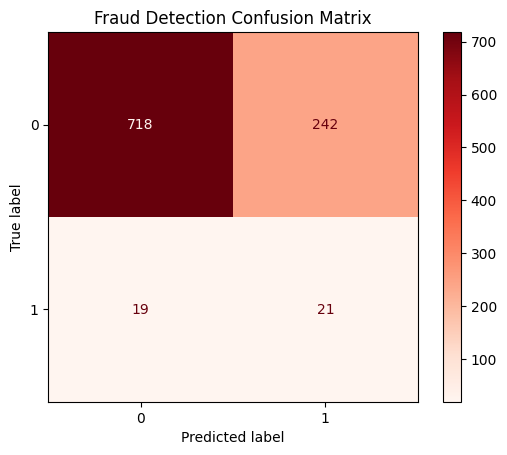

In [149]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    pipeline,
    X_test,
    y_test,
    cmap='Reds'
)

plt.title("Fraud Detection Confusion Matrix")
plt.show()

## Model Explainability: Key Fraud Risk Drivers

This section identifies which features contribute most strongly to fraud prediction.

Feature importance helps support explainable fraud investigation by showing which behavioral, transaction, customer, and merchant attributes influence model decisions.

This is important because fraud analysts need to understand not only whether a transaction is risky, but also why it was flagged.

In [150]:
from sklearn.inspection import permutation_importance
import pandas as pd
import matplotlib.pyplot as plt

result = permutation_importance(
    pipeline,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring='roc_auc'
)

feature_importance = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance': result.importances_mean
}).sort_values(by='Importance', ascending=False)

feature_importance.head(10)

,Feature,Importance
6,geo_distance_km,0.030870
21,channel_P2P,0.024854
18,risk_gap,0.024841
0,transaction_amount_usd,0.020021
24,txn_country_CA,0.014404
248,merchant_category_Fuel,0.011992
245,home_country_UK,0.010708
4,velocity_1h,0.010698
27,txn_country_IN,0.010693
101,tenure_months_1970-03-12,0.009719


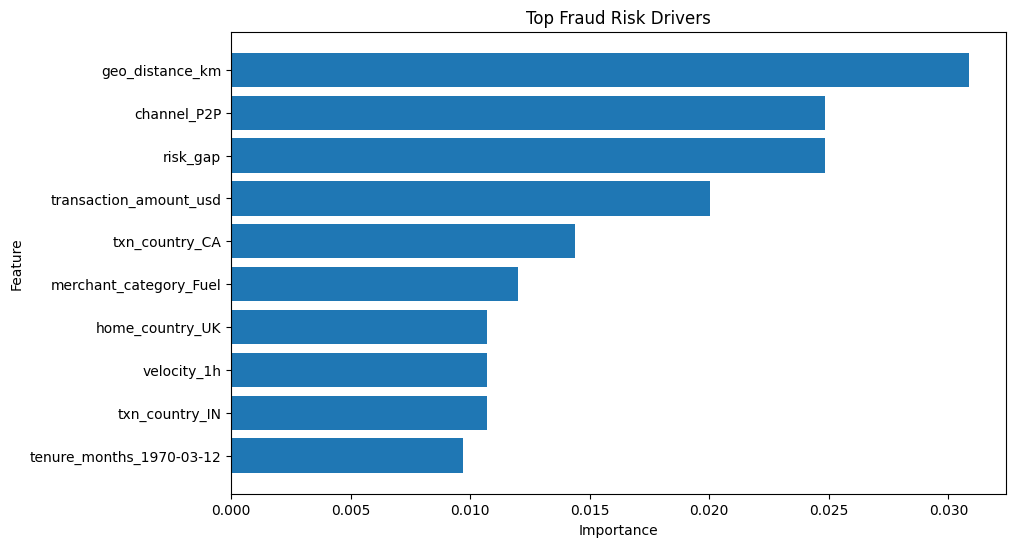

In [151]:
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance['Feature'].head(10),
    feature_importance['Importance'].head(10)
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top Fraud Risk Drivers")
plt.gca().invert_yaxis()
plt.show()

## Feature Importance Interpretation

The feature importance chart identifies the strongest drivers influencing the fraud prediction model.

These drivers help explain why certain transactions are more likely to be flagged as risky. This supports investigator trust because fraud analysts can connect model outputs to understandable business signals such as transaction behavior, customer risk, merchant activity, device usage, and timing patterns.

This explainability layer is important because fraud operations teams need transparent rationale when prioritizing alerts, not just a prediction score.

## Operational Interpretation of Model Performance

The confusion matrix highlights the tradeoff between fraud detection recall and operational false positives.

In fraud operations:
- False negatives represent missed fraudulent transactions,
- False positives increase investigator review workload,
- and threshold selection directly impacts queue efficiency.

The objective of the fraud prioritisation framework is therefore not only to maximize prediction accuracy, but also to balance:
- fraud capture,
- operational scalability,
- investigator workload,
- and explainable alert prioritisation.

## Model Evaluation and Interpretation

The Logistic Regression model achieved an ROC-AUC score of 0.64, indicating moderate ability to distinguish between fraudulent and legitimate transactions.

The model achieved a recall of 0.50 for the fraud class, meaning that 50% of fraudulent transactions were successfully identified.

Recall is prioritized in fraud detection because missing fraudulent activity is more costly than generating additional alerts.

However, precision for fraud detection was relatively low (0.08), indicating a high number of false positive alerts. This suggests that while the model captures fraud cases reasonably well, further optimization is required to reduce unnecessary fraud alerts.

Overall, the Logistic Regression model serves as a useful baseline model for fraud risk detection and demonstrates the complete machine learning workflow from preprocessing to evaluation.


## Cross-Validation

Model performance was further evaluated using **5-fold Stratified Cross-Validation** to assess whether the selected Logistic Regression model generalises consistently across different subsets of the dataset.

Unlike a single train-test split, cross-validation repeatedly trains and evaluates the model while preserving the fraud class distribution in each fold. This provides a more reliable estimate of expected performance and reduces the likelihood that evaluation results are dependent on one specific data split.

Since fraud detection datasets are typically imbalanced, **Stratified K-Folds** were selected to ensure that each validation fold maintained a representative proportion of fraudulent and legitimate transactions.

In [152]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Configure 5-fold stratified cross-validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Evaluate Logistic Regression using ROC-AUC
cv_scores = cross_val_score(
    pipeline,
    X,
    y,
    cv=cv,
    scoring="roc_auc"
)

cv_results = pd.DataFrame({
    "Fold": [1, 2, 3, 4, 5],
    "ROC-AUC": cv_scores
})

cv_results

,Fold,ROC-AUC
0,1,0.637865
1,2,0.542135
2,3,0.633828
3,4,0.620260
4,5,0.625931


In [153]:
cv_summary = pd.DataFrame({
    "Metric": ["Mean ROC-AUC", "Standard Deviation"],
    "Value": [
        round(cv_scores.mean(), 3),
        round(cv_scores.std(), 3)
    ]
})

cv_summary

,Metric,Value
0,Mean ROC-AUC,0.612
1,Standard Deviation,0.035


### Cross-Validation Interpretation

The selected Logistic Regression model achieved a mean ROC-AUC of 0.612 across five stratified validation folds, with a standard deviation of 0.035.

The relatively small variation between folds indicates that model performance remains reasonably consistent across different subsets of the data and is not heavily dependent on a single train-test split.

Although individual fold performance varies slightly, the overall results demonstrate acceptable generalisation for an operational fraud prioritisation framework. Further validation using real-world production data would be recommended before deployment.

## Evaluation Metrics for Fraud Detection

Model evaluation was performed using multiple complementary metrics rather than relying solely on overall accuracy.

Due to the significant class imbalance within the dataset, accuracy alone is not an appropriate indicator of fraud detection performance, as a model may achieve high accuracy while failing to identify fraudulent transactions.

The following metrics were considered during model evaluation:

- **Recall** – measures the proportion of fraudulent transactions correctly identified and supports fraud capture.
- **Precision** – indicates the proportion of predicted fraud alerts that are genuinely fraudulent and influences investigator workload.
- **ROC-AUC** – evaluates the model's ability to distinguish fraudulent from legitimate transactions across different classification thresholds.
- **Confusion Matrix** – provides operational visibility into true positives, false positives, false negatives and true negatives.

Together, these metrics provide a balanced assessment of fraud detection effectiveness while supporting operational decision-making.

### Operational Interpretation

Within fraud operations, the consequences of missing fraudulent transactions are generally greater than reviewing a manageable number of additional alerts.

For this reason, the selected Logistic Regression model was evaluated using multiple performance measures alongside business-led threshold analysis rather than accuracy alone.

This evaluation approach supports the project's objective of balancing fraud detection capability with investigator workload and operational efficiency.

## Business-Led Threshold Comparison

Fraud thresholds should be selected based on risk appetite and investigator capacity rather than model accuracy alone.

Three operational strategies are compared:

- Conservative: fewer alerts and lower investigation workload, but increased missed fraud exposure.
- Balanced: moderate fraud coverage with manageable investigation volumes.
- Aggressive: higher fraud capture but increased false positives and investigation workload.

The recommended operating threshold should balance fraud detection effectiveness, alert quality, and investigator scalability.

In [154]:
from sklearn.metrics import precision_score, recall_score, confusion_matrix

# Threshold comparison for Logistic Regression probabilities

threshold_options = {
    "Conservative": 0.70,
    "Balanced": 0.50,
    "Aggressive": 0.30
}

threshold_results = []

for option, threshold in threshold_options.items():
    threshold_pred = (y_prob >= threshold).astype(int)
    
    tn, fp, fn, tp = confusion_matrix(y_test, threshold_pred).ravel()
    
    alerts_flagged = int(threshold_pred.sum())
    precision = precision_score(y_test, threshold_pred, zero_division=0)
    recall = recall_score(y_test, threshold_pred, zero_division=0)
    false_positive_rate = fp / (fp + tn) if (fp + tn) > 0 else 0
    queue_hit_rate = tp / (tp + fp) if (tp + fp) > 0 else 0
    
    threshold_results.append({
        "Operating Option": option,
        "Threshold": threshold,
        "Alerts Flagged": alerts_flagged,
        "Precision": round(precision, 3),
        "Recall": round(recall, 3),
        "False Positives": int(fp),
        "False Negatives": int(fn),
        "False Positive Rate": round(false_positive_rate, 3),
        "Queue Hit Rate": round(queue_hit_rate, 3),
        "Estimated Investigator Cases": alerts_flagged
    })

threshold_comparison = pd.DataFrame(threshold_results)

threshold_comparison

,Operating Option,Threshold,Alerts Flagged,Precision,Recall,False Positives,False Negatives,False Positive Rate,Queue Hit Rate,Estimated Investigator Cases
0,Conservative,0.7,95,0.084,0.200,87,32,0.091,0.084,95
1,Balanced,0.5,263,0.080,0.525,242,19,0.252,0.080,263
2,Aggressive,0.3,547,0.049,0.675,520,13,0.542,0.049,547


### Threshold Recommendation

The balanced threshold (0.50) is recommended as the prototype operating point because it provides a practical compromise between fraud coverage and investigation workload.

The aggressive threshold captures more fraud but substantially increases investigation volume and false-positive exposure.

The conservative threshold reduces operational workload but allows a larger proportion of fraudulent activity to remain undetected.

For fraud operations teams, threshold selection is therefore a business decision rather than a modelling decision. The chosen threshold should reflect fraud-loss tolerance, investigation capacity, and operational service-level objectives.

In [155]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [156]:
# Import XGBoost classifier
# XGBoost is an advanced gradient boosting algorithm widely used in fraud detection

from xgboost import XGBClassifier

In [157]:
# Create XGBoost fraud detection model

# Key configurations:
# - n_estimators controls number of boosting trees
# - max_depth controls tree complexity
# - learning_rate controls how quickly the model learns
# - scale_pos_weight helps handle fraud class imbalance
# - random_state ensures reproducible results
# - eval_metric avoids default warning messages

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=24,
    random_state=42,
    eval_metric="logloss"
)

In [158]:
# Train XGBoost fraud detection model
xgb_model.fit(X_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_metho

In [159]:
# Generate fraud predictions using XGBoost model

# Predict fraud labels on unseen test data

xgb_pred = xgb_model.predict(X_test)

# Predict fraud probabilities
# These probabilities are used for ROC-AUC evaluation

xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

In [160]:
# XGBoost was evaluated as a benchmark model to compare performance against the selected Logistic Regression operational model.

print("XGBoost ROC-AUC Score:", roc_auc_score(y_test, xgb_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, xgb_pred))

print("\nClassification Report:")
print(classification_report(y_test, xgb_pred))

XGBoost ROC-AUC Score: 0.6017708333333334

Confusion Matrix:
[[856 104]
 [ 32   8]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.89      0.93       960
           1       0.07      0.20      0.11        40

    accuracy                           0.86      1000
   macro avg       0.52      0.55      0.52      1000
weighted avg       0.93      0.86      0.89      1000



In [161]:
# Final model comparison table for report

from sklearn.metrics import precision_score, recall_score, roc_auc_score

model_comparison_table = pd.DataFrame({
    "Metric": [
        "ROC-AUC",
        "Fraud Precision",
        "Fraud Recall",
        "Operational Explainability",
        "Operational Role"
    ],
    "Logistic Regression": [
        round(roc_auc_score(y_test, y_prob), 3),
        round(precision_score(y_test, y_pred, zero_division=0), 3),
        round(recall_score(y_test, y_pred, zero_division=0), 3),
        "High",
        "Selected Operational Model"
    ],
    "XGBoost": [
        round(roc_auc_score(y_test, xgb_prob), 3),
        round(precision_score(y_test, xgb_pred, zero_division=0), 3),
        round(recall_score(y_test, xgb_pred, zero_division=0), 3),
        "Moderate",
        "Benchmark Model for SHAP"
    ]
})

model_comparison_table

,Metric,Logistic Regression,XGBoost
0,ROC-AUC,0.628,0.602
1,Fraud Precision,0.08,0.071
2,Fraud Recall,0.525,0.2
3,Operational Explainability,High,Moderate
4,Operational Role,Selected Operational Model,Benchmark Model for SHAP


In [162]:
%pip install shap

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [163]:
import shap

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

print("SHAP values generated successfully")

SHAP values generated successfully


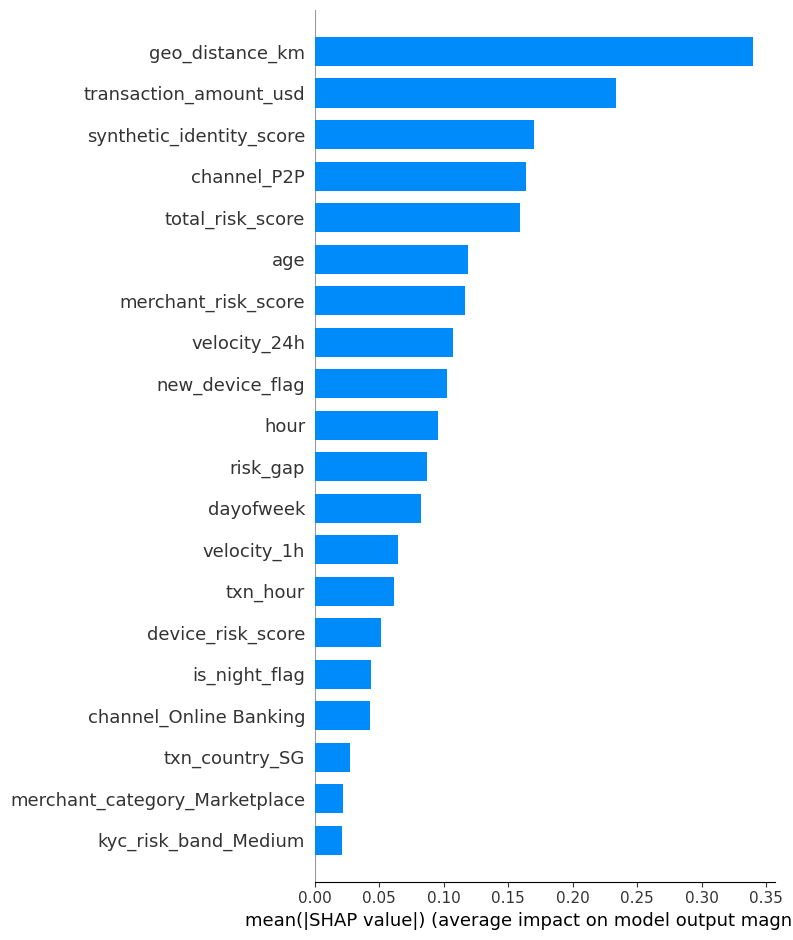

In [164]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)

## Local SHAP Explanation

SHAP explainability is demonstrated using the XGBoost benchmark model to illustrate transaction-level model interpretability.

Although Logistic Regression was selected as the preferred operational model, XGBoost was additionally analysed because tree-based models provide richer SHAP visualisations. This demonstrates how explainable AI techniques can support investigator understanding regardless of the final operational model selected.

The following example illustrates how SHAP explains why an individual transaction received a higher fraud-risk prediction.

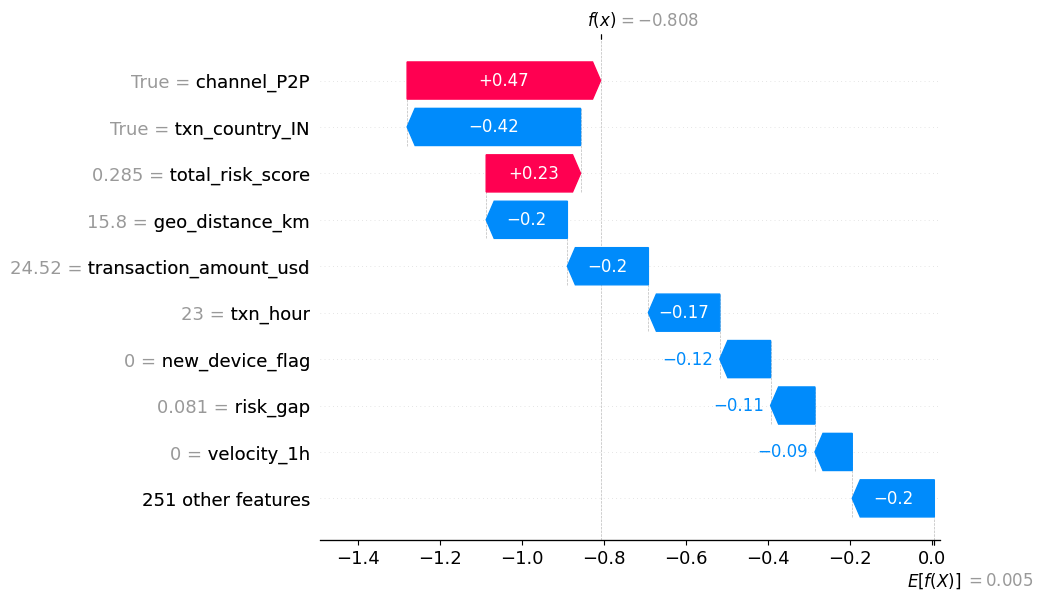

In [165]:
# Select one transaction for local SHAP explanation

transaction_index = 25

shap.plots.waterfall(
    explainer(X_test.iloc[[transaction_index]])[0],
    max_display=10
)

### Local SHAP Interpretation

The selected transaction demonstrates how SHAP provides transparent, transaction-level explanations for fraud predictions.

For this example, the **P2P transaction channel** and the **overall risk score** increased the predicted fraud risk, while factors including the **transaction country (India)**, **transaction amount**, **geographical distance**, **transaction hour**, and the absence of a **new device** reduced the overall risk score.

Rather than producing a black-box prediction, the model clearly identifies which behavioural and transactional characteristics contributed positively or negatively to the final fraud-risk assessment.

Although this example is generated using the benchmark XGBoost model, the explainability principles demonstrated are equally applicable to operational fraud investigation workflows and complement the selected Logistic Regression framework.





## Responsible AI, Fairness and Ethical Considerations

Fraud detection models should support investigator decision-making while maintaining transparency, fairness and operational accountability.

Although the dataset used in this project is synthetic, several governance principles were incorporated to encourage responsible model development and deployment.

### Responsible AI Controls

The following controls were incorporated throughout the modelling process:

- Protected demographic characteristics were not intentionally engineered as predictive features.
- Operational alert flags were excluded from model training to prevent target leakage.
- SHAP explainability was used to improve transparency and support investigator understanding.
- High-risk alerts remain subject to human review before operational action.
- Threshold selection is treated as a business decision balancing fraud detection against investigator workload.
- The framework is intended to support analysts rather than replace operational judgement.

### Fairness and Ethical Considerations

The project does not assume that model predictions should be acted upon automatically.

Instead, fraud-risk scores provide decision support for investigators, who retain responsibility for reviewing evidence, validating suspicious activity and determining appropriate escalation actions.

Future production deployment should include ongoing performance monitoring, model drift detection, periodic threshold reviews and fairness assessments using real operational data.

# Operational KPI Framework

This section translates the outputs of the selected **Logistic Regression** model into operational fraud investigation metrics that support investigator decision-making.

While traditional machine learning evaluation focuses on predictive performance, fraud operations also require an understanding of how model outputs affect investigation workload, alert quality and fraud detection effectiveness. The following operational KPIs demonstrate how the selected model can support business decision-making beyond standard classification metrics.

The operational KPIs include:

* **Fraud Precision** – measures the proportion of generated alerts that represent genuine fraudulent transactions, reflecting alert quality.
* **Fraud Recall** – measures the proportion of fraudulent transactions successfully identified by the model, representing fraud detection coverage.
* **False Positive Rate** – measures the proportion of legitimate transactions incorrectly flagged for investigation, indicating unnecessary operational workload.
* **Queue Hit Rate** – measures the proportion of investigation queue alerts that are confirmed as fraud, reflecting investigator productivity.
* **Average Triage Score** – represents the average predicted fraud probability of generated alerts, supporting risk-based investigation prioritisation.
* **Alert Volume** – measures the number of transactions referred for manual investigation.
* **Total Test Cases** – represents the number of transactions evaluated during operational performance assessment.


In [166]:
# Operational KPI calculations using the selected Logistic Regression model

operational_threshold = 0.50

# Generate operational alerts from Logistic Regression fraud probabilities
alert_generated = (y_prob >= operational_threshold).astype(int)

# Confusion matrix components
tn, fp, fn, tp = confusion_matrix(y_test, alert_generated).ravel()

# Operational KPI calculations
fraud_precision = precision_score(y_test, alert_generated, zero_division=0)
fraud_recall = recall_score(y_test, alert_generated, zero_division=0)
false_positive_rate = fp / (fp + tn) if (fp + tn) > 0 else 0
queue_hit_rate = tp / (tp + fp) if (tp + fp) > 0 else 0
average_triage_score = y_prob[alert_generated == 1].mean() if alert_generated.sum() > 0 else 0
alert_volume = alert_generated.sum()
total_cases = len(alert_generated)

operational_kpis = pd.DataFrame({
    "KPI": [
        "Fraud Precision",
        "Fraud Recall",
        "False Positive Rate",
        "Queue Hit Rate",
        "Average Triage Score",
        "Alert Volume",
        "Total Test Cases"
    ],
    "Value": [
        round(fraud_precision, 3),
        round(fraud_recall, 3),
        round(false_positive_rate, 3),
        round(queue_hit_rate, 3),
        round(average_triage_score, 3),
        alert_volume,
        total_cases
    ],
    "Business Meaning": [
        "Share of flagged alerts that were actually fraud",
        "Share of actual fraud cases captured by the alerting logic",
        "Share of non-fraud cases incorrectly flagged for investigation",
        "Investigator productivity based on confirmed fraud within the alert queue",
        "Average Logistic Regression fraud probability among generated alerts",
        "Number of transactions sent to the investigation queue",
        "Total number of transactions evaluated in the test sample"
    ]
})

operational_kpis

,KPI,Value,Business Meaning
0,Fraud Precision,0.080,Share of flagged alerts that were actually fraud
1,Fraud Recall,0.525,Share of actual fraud cases captured by the al...
2,False Positive Rate,0.252,Share of non-fraud cases incorrectly flagged f...
3,Queue Hit Rate,0.080,Investigator productivity based on confirmed f...
4,Average Triage Score,0.676,Average Logistic Regression fraud probability ...
5,Alert Volume,263.000,Number of transactions sent to the investigati...
6,Total Test Cases,1000.000,Total number of transactions evaluated in the ...


## Operational KPI Definitions

The following operational KPIs were calculated using the selected Logistic Regression model to evaluate how fraud predictions translate into investigator workload, alert quality and operational effectiveness.

| KPI | Operational Definition | Business Purpose |
|---|---|---|
| Fraud Precision | Share of generated alerts that were confirmed as fraud | Measures alert quality and investigation efficiency |
| Fraud Recall | Share of actual fraud cases captured by the alerting workflow | Measures fraud detection coverage |
| False Positive Rate | Share of non-fraud transactions incorrectly escalated | Measures operational investigation waste |
| Queue Hit Rate | Share of investigated alerts that resulted in confirmed fraud | Measures investigator productivity |
| Average Triage Score | Average predicted Logistic Regression fraud probability among escalated alerts | Measures overall queue severity |
| Alert Volume | Number of transactions escalated for review | Measures operational investigation workload |

These KPIs demonstrate how the selected operational model can be evaluated from a fraud operations perspective by balancing fraud detection performance, investigation workload and operational efficiency, rather than relying solely on traditional machine learning performance metrics.

## Threshold Strategy and Operational Tradeoffs

The selected operating threshold should be governed as an operational decision rather than a fixed technical setting.

Threshold changes directly affect fraud recall, alert quality, false positives and investigator workload. For this reason, threshold performance should be reviewed periodically against fraud trends, investigation capacity and business risk appetite.

The business-led threshold comparison above provides the initial prototype operating point, while future production use would require ongoing monitoring and recalibration.

## Governance, Explainability, and Operational Monitoring

Fraud detection systems require continuous monitoring, explainability, and governance controls to maintain operational effectiveness and investigator trust.

The fraud prioritisation framework in this project is designed to support investigators rather than replace human judgment.

Several governance considerations are important in real-world fraud operations environments:

- Fraud behavior evolves over time and may introduce model drift
- Threshold strategies may require recalibration as alert volumes change
- False positives can increase operational investigation workload
- Explainability is required for investigator trust and operational transparency
- High-risk alerts should support clear escalation rationale
- Human analyst review remains critical for complex fraud investigations
- SLA adherence should be monitored to ensure timely review of high-risk alerts

The governance framework is operationalised through transaction-level reason codes, recommended actions, and SLA-based alert prioritisation. These controls provide transparency into why transactions are escalated, support consistent investigator decision-making, and improve auditability across the fraud review process.

The operational dashboard and explainability framework were therefore designed to improve:
- investigator efficiency,
- fraud triage transparency,
- and explainable operational decision-making.

# Operational Fraud Model Card

## Model Overview

This project implements **Logistic Regression** as the selected operational model within an explainable fraud intelligence framework developed for simulated banking fraud operations.

The framework combines behavioural analytics, machine learning, operational dashboards and explainable AI to support fraud-alert prioritisation, investigator decision-making and operational governance.

Logistic Regression was selected following comparative evaluation because it provided the strongest balance between fraud detection capability, explainability, operational transparency and business suitability for investigator-led fraud prioritisation.

---

## Intended Use

The framework is intended to support:

* fraud-risk prioritisation;
* investigator alert triage;
* operational fraud monitoring;
* explainable fraud analytics;
* operational KPI monitoring; and
* decision support within simulated fraud operations.

The framework is **not intended** for autonomous fraud decisions, automatic customer blocking or production banking deployment without additional validation and governance.

---

## Operational Scope

* **Unit of analysis:** One transaction
* **Target variable:** `fraud_label`
* **Selected operational model:** Logistic Regression
* **Operational alert logic:** Threshold-based fraud alert generation
* **Benchmark model:** XGBoost (used for comparative evaluation and SHAP explainability)

---

## Key Features

The selected model incorporates behavioural, transactional and entity-level fraud indicators, including:

* transaction characteristics;
* customer risk attributes;
* merchant risk indicators;
* transaction velocity;
* device familiarity;
* transaction timing;
* geographic anomalies;
* transaction channel exposure; and
* synthetic identity indicators.

These features support both fraud prediction and operational fraud prioritisation.

---

## Operational Performance Measures

Operational effectiveness is evaluated using:

* Fraud Precision
* Fraud Recall
* False Positive Rate
* Queue Hit Rate
* Average Triage Score
* Alert Volume

These operational KPIs evaluate fraud detection performance alongside investigator workload, queue quality and operational efficiency rather than relying solely on traditional machine learning metrics.

---

## Risk Prioritisation Framework

Model outputs are translated into operational investigation actions through three risk tiers:

* **High Risk** → Same Day Review
* **Medium Risk** → Analyst Review Within 24 Hours
* **Low Risk** → Weekly Monitoring

Each alert is further supported through recommended actions, transaction-level reason codes and SLA-based prioritisation to improve investigator workflow efficiency and operational transparency.

---

## Explainability and Governance

The framework incorporates multiple explainability and governance controls, including:

* permutation feature importance analysis;
* SHAP transaction-level explainability (demonstrated using the benchmark XGBoost model);
* transaction-level reason codes;
* threshold governance;
* operational KPI monitoring;
* human-in-the-loop review; and
* Responsible AI principles.

These controls improve transparency, auditability and investigator confidence throughout the fraud review process.

---

## Assumptions and Limitations

* The dataset is synthetic and intended for analytical demonstration.
* Operational thresholds represent prototype decision points rather than production calibration.
* Fraud behaviour may differ in live banking environments.
* Operational KPIs simulate investigator workflows rather than live operational performance.
* Human investigator judgement remains essential for complex fraud investigations.

---

## Monitoring Considerations

Future operational deployment should include:

* threshold recalibration;
* model performance monitoring;
* model drift detection;
* investigator feedback integration;
* fairness assessment;
* governance reviews; and
* periodic validation against operational KPIs to ensure continued fraud detection effectiveness and operational suitability.


## Investigator Dashboard Integration

The fraud intelligence framework was operationalised through an interactive Power BI dashboard designed to support investigator workflows and fraud triage operations.

The dashboard environment consists of six integrated analytical views:

- Executive Overview
- Operational Fraud Analysis
- Customer & Behavioural Intelligence
- Explainable Fraud Prioritisation
- Fraud Operations & Queue Management
- Operational Effectiveness Monitoring

Together, these views provide a comprehensive operational fraud intelligence environment supporting fraud monitoring, investigation prioritisation, investigator workflows, and operational performance tracking.

Key dashboard capabilities include:
- fraud risk segmentation,
- operational alert prioritisation,
- behavioral fraud pattern analysis,
- merchant concentration analysis,
- transaction channel monitoring,
- SLA-based alert management,
- transaction-level reason codes,
- recommended investigation actions,
- and investigation queue management.

The dashboard integration layer improves:
- operational transparency,
- investigator efficiency,
- explainability of fraud alerts,
- and fraud investigation prioritisation.

## Tools and Technologies Used

- Python
- pandas
- scikit-learn
- XGBoost
- matplotlib
- Jupyter Notebook / VS Code

The analysis workflow was implemented entirely within Python using pandas-based data processing and machine learning libraries.

# Dashboard Dataset Preparation and Operational Validation

This section checks for missing values, duplicates, and datatype inconsistencies before further analysis.

In [167]:
# Converting the transaction timestamp

In [168]:
transactions['event_ts'] = pd.to_datetime(transactions['event_ts'])

# Validating Dataset Relationships

This section validates whether transaction records successfully match customer and merchant records across datasets.

Relationship validation is important because:
- it ensures data consistency,
- supports reliable dataset merging,
- and confirms the integrity of multi-entity fraud analysis.

Successful relationship matching enables customer-level and merchant-level fraud intelligence generation.

In [169]:
transactions['customer_id'].isin(customers['customer_id']).mean()

np.float64(0.8356)

# Customer Relationship Integrity Analysis

The relationship validation process identified that not all transaction customer IDs successfully matched records in the customer dataset.

Approximately 16% of transaction records contain customer IDs that are missing from the customer dataset.

This may indicate:
- incomplete onboarding records,
- data synchronization issues,
- unidentified customer activity,
- or potential operational inconsistencies.

This observation is important because incomplete entity relationships may impact fraud investigation accuracy and customer-level risk analysis.

In [170]:
missing_customers = transactions[
    ~transactions['customer_id'].isin(customers['customer_id'])
]

missing_customers.head()

,transaction_id,event_ts,customer_id,merchant_id,channel,transaction_amount_usd,txn_country,txn_hour,device_risk_score,new_device_flag,velocity_1h,velocity_24h,geo_distance_km,merchant_risk_score,is_night_flag,alert_generated,fraud_label
3,T9014668,2025-02-24 19:35:00,C100003,M100003,Card Present,97.55,US,6,0.125,0,3,5,30.5,0.632,0,0,0
4,T9057899,2025-01-30 14:22:00,C100004,M100004,Online Banking,160.49,AE,12,0.138,0,1,3,3.1,0.097,0,0,0
5,T9033198,2025-03-16 07:26:00,C100005,M100005,Card Present,11.27,IN,5,0.215,0,1,2,53.7,0.378,1,0,0
9,T9053944,2025-03-11 02:30:00,C100009,M100009,P2P,298.57,IN,18,0.204,1,0,2,22.2,0.143,0,0,0
16,T9008668,2025-01-04 09:47:00,C100016,M100016,Card Present,140.39,US,20,0.171,0,1,4,19.3,0.120,0,0,0


# Measuring Missing Customer Relationships

This step calculates the number of transaction records associated with customer IDs that do not exist in the customer dataset.

Quantifying missing relationships helps evaluate the scale of data integrity issues and their potential operational impact.

In [171]:
missing_customers.shape

(822, 17)

# Identifying Unique Missing Customer IDs

This step identifies the number of unique customer IDs missing from the customer dataset.

This helps determine whether the issue is caused by:
- a few repeatedly missing customers,
- or widespread customer data inconsistencies.

In [172]:
missing_customers['customer_id'].nunique()

822

# Merchant Relationship Integrity Analysis

This section investigates whether all merchant IDs present in the transaction dataset successfully match records in the merchant dataset.

Missing merchant relationships may indicate:
- incomplete merchant onboarding,
- synchronization failures,
- unsupported merchant transactions,
- or operational data inconsistencies.

Understanding merchant relationship quality is important for reliable merchant-level fraud intelligence.

In [173]:
missing_merchants = transactions[
    ~transactions['merchant_id'].isin(merchants['merchant_id'])
]

missing_merchants.head()

,transaction_id,event_ts,customer_id,merchant_id,channel,transaction_amount_usd,txn_country,txn_hour,device_risk_score,new_device_flag,velocity_1h,velocity_24h,geo_distance_km,merchant_risk_score,is_night_flag,alert_generated,fraud_label


# Measuring Missing Merchant Relationships

This step calculates the number of transaction records associated with merchant IDs missing from the merchant dataset.

Quantifying missing merchant relationships helps assess the reliability of merchant-level analytics and fraud ecosystem analysis.

In [174]:
missing_merchants.shape

(0, 17)

# Identifying Unique Missing Merchant IDs

This step identifies the number of unique merchant IDs missing from the merchant dataset.

This helps determine whether merchant inconsistencies are concentrated among a few merchants or spread across multiple entities.

In [175]:
missing_merchants['merchant_id'].nunique()

0

# Fraud Analysis for Missing Customer Relationships

This section compares fraud activity between:
- transactions linked to valid customer records,
- and transactions associated with missing customer IDs.

This analysis helps determine whether incomplete customer relationships are correlated with elevated fraud activity.

In [176]:
transactions['customer_match'] = transactions['customer_id'].isin(customers['customer_id'])

transactions.groupby('customer_match')['fraud_label'].mean() * 100

customer_match
False    4.136253
True     3.997128
Name: fraud_label, dtype: float64

# Fraud Analysis for Missing Merchant Relationships

This section compares fraud activity between:
- transactions linked to valid merchant records,
- and transactions associated with missing merchant IDs.

This helps evaluate whether incomplete merchant relationships are associated with increased fraud exposure.

In [177]:
transactions['merchant_match'] = transactions['merchant_id'].isin(merchants['merchant_id'])

transactions.groupby('merchant_match')['fraud_label'].mean() * 100

merchant_match
True    4.02
Name: fraud_label, dtype: float64

# Merging Customer Data

This section merges customer-level information into the transaction dataset using the customer_id key.

Customer enrichment enables:
- customer behavior analysis,
- customer risk profiling,
- demographic fraud analysis,
- and multi-entity fraud intelligence generation.

In [178]:
merged_data = transactions.merge(
    customers,
    on='customer_id',
    how='left'
)

# Merging Merchant Data

This section merges merchant-level information into the transaction dataset using the merchant_id key.

Merchant enrichment enables:
- merchant ecosystem analysis,
- merchant risk profiling,
- and fraud concentration analysis across merchant entities.

In [179]:
merged_data = merged_data.merge(
    merchants,
    on='merchant_id',
    how='left'
)

# Inspecting the Enriched Master Dataset

This section inspects the merged analytical dataset after combining:
- transaction data,
- customer data,
- and merchant data.

The resulting master dataset supports integrated fraud intelligence analysis across multiple entities.

In [180]:
merged_data.head()

,transaction_id,event_ts,customer_id,merchant_id,channel,transaction_amount_usd,txn_country,txn_hour,device_risk_score,new_device_flag,...,age,tenure_months,segment,home_country,digital_only,kyc_risk_band,synthetic_identity_score,merchant_category,merchant_risk_score_y,channel_default
0,T9028450,2025-01-12 06:38:00,C100000,M100000,Card Present,70.46,US,4,0.747,1,...,32.0,1970-04-26,Affluent,US,1.0,Medium,0.084,Utilities,0.554,Card Not Present
1,T9050670,2025-01-20 04:18:00,C100001,M100001,P2P,36.12,DE,3,0.197,0,...,64.0,1970-07-02,Mass,IN,1.0,Low,0.279,Digital Wallet,0.162,P2P
2,T9015811,2025-03-16 21:19:00,C100002,M100002,Card Not Present,156.38,SG,10,0.393,0,...,49.0,1970-07-10,SME,IN,1.0,Low,0.269,Travel,0.449,Card Not Present
3,T9014668,2025-02-24 19:35:00,C100003,M100003,Card Present,97.55,US,6,0.125,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Electronics,0.315,Online Banking
4,T9057899,2025-01-30 14:22:00,C100004,M100004,Online Banking,160.49,AE,12,0.138,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Telecom,0.079,Online Banking


In [181]:
merged_data.shape

(5000, 29)

# Evaluating Missing Values After Dataset Integration

This step identifies missing values introduced during dataset merging.

Post-merge missing values are important because they may indicate:
- incomplete customer relationships,
- onboarding gaps,
- missing merchant attributes,
- or integration inconsistencies.

Understanding post-merge data quality is critical before advanced fraud analysis.

In [182]:
merged_data.isnull().sum()

transaction_id                0
event_ts                      0
customer_id                   0
merchant_id                   0
channel                       0
transaction_amount_usd        0
txn_country                   0
txn_hour                      0
device_risk_score             0
new_device_flag               0
velocity_1h                   0
velocity_24h                  0
geo_distance_km               0
merchant_risk_score_x         0
is_night_flag                 0
alert_generated               0
fraud_label                   0
customer_match                0
merchant_match                0
age                         822
tenure_months               822
segment                     822
home_country                822
digital_only                822
kyc_risk_band               822
synthetic_identity_score    822
merchant_category             0
merchant_risk_score_y         0
channel_default               0
dtype: int64

# Fraud Analysis by Customer Segment

This section analyses fraud distribution across customer segments.

Customer segmentation analysis helps identify:
- high-risk customer groups,
- behavioral fraud concentration,
- and segment-level exposure patterns.

Segment-based fraud intelligence supports targeted monitoring and risk prioritisation strategies.

In [183]:
merged_data.groupby('segment')['fraud_label'].mean() * 100

segment
Affluent    4.295943
Mass        3.900826
SME         4.126984
Name: fraud_label, dtype: float64

# Fraud Analysis by KYC Risk Band

This section evaluates fraud rates across KYC (Know Your Customer) risk bands.

KYC risk analysis helps determine whether:
- customers already classified as high-risk,
- are also associated with elevated fraud activity.

This supports explainable fraud intelligence and operational risk assessment validation.

In [184]:
merged_data.groupby('kyc_risk_band')['fraud_label'].mean() * 100

kyc_risk_band
High      3.636364
Low       4.008992
Medium    4.071247
Name: fraud_label, dtype: float64

# Fraud Analysis by Merchant Category

This section evaluates fraud exposure across different merchant categories.

Merchant category analysis helps identify:
- industries associated with elevated fraud activity,
- high-risk transaction ecosystems,
- and operational fraud concentration patterns.

In [185]:
merged_data.groupby('merchant_category')['fraud_label'].mean().sort_values(ascending=False) * 100

merchant_category
Fuel              4.971319
Utilities         4.572565
Gaming            4.400607
Electronics       4.261796
Luxury            4.230118
Telecom           3.744493
Grocery           3.577236
Marketplace       3.389831
Digital Wallet    3.108808
Travel            2.839117
Name: fraud_label, dtype: float64

# Fraud Analysis by Transaction Channel

This section analyses fraud distribution across transaction channels.

Channel-level fraud analysis helps identify:
- vulnerable transaction environments,
- digital fraud exposure,
- and operational channel risk concentration.

In [186]:
merged_data.groupby('channel')['fraud_label'].mean() * 100

channel
Card Not Present    2.869440
Card Present        3.793329
Online Banking      3.201708
P2P                 6.534422
Wire                6.007067
Name: fraud_label, dtype: float64

# Fraud Analysis for Night-Time Transactions

This section compares fraud rates between:
- daytime transactions,
- and night-time transactions.

Time-based fraud analysis helps identify behavioral fraud patterns and unusual transaction timing activity.

In [187]:
merged_data.groupby('is_night_flag')['fraud_label'].mean() * 100

is_night_flag
0    3.479749
1    5.287818
Name: fraud_label, dtype: float64

# Fraud Analysis for New Device Activity

This section evaluates fraud exposure associated with transactions performed using new devices.

New device activity is an important fraud signal because:
- fraudsters frequently use unfamiliar devices,
- compromised accounts may exhibit device changes,
- and unusual device behavior may indicate elevated transaction risk.

In [188]:
merged_data.groupby('new_device_flag')['fraud_label'].mean() * 100

new_device_flag
0    3.636807
1    5.758583
Name: fraud_label, dtype: float64

# Key Fraud Intelligence Findings

The analysis identified several important fraud behavior patterns across customers, merchants, transaction channels, and behavioral signals.

## Key Observations

### Customer Segment Analysis
- Affluent customers demonstrated slightly higher fraud exposure compared to other customer segments.
- Fraud activity was relatively distributed across all customer groups, indicating fraud is not isolated to a single segment.

### KYC Risk Band Analysis
- Existing KYC risk classifications did not strongly differentiate fraud exposure.
- Fraud rates were relatively similar across Low, Medium, and High KYC categories, suggesting transactional behavior may be more predictive than static onboarding risk profiles.

### Merchant Category Analysis
- Fuel, Utilities, and Gaming merchants showed the highest fraud exposure.
- Travel and Digital Wallet merchants demonstrated comparatively lower fraud rates.

### Transaction Channel Analysis
- P2P and Wire transactions exhibited significantly elevated fraud rates compared to other channels.
- These channels may require enhanced monitoring and transaction review workflows.

### Behavioral Fraud Signals
- Night-time transactions showed materially higher fraud exposure.
- Transactions involving new devices demonstrated significantly elevated fraud rates.

These findings support the development of an explainable fraud prioritisation framework focused on behavioral and transactional risk signals.

# Building Explainable Fraud Risk Intelligence Framework

This section develops an explainable fraud risk scoring framework using behavioral and transactional fraud indicators identified during exploratory analysis.

Unlike black-box fraud models, this framework provides transparent and interpretable risk prioritisation logic.

The scoring model incorporates:
- device risk,
- merchant risk,
- transaction velocity,
- new device activity,
- night-time behavior,
- geographic anomalies,
- and high-risk transaction channels.

Higher scores indicate elevated fraud exposure and investigation priority.

In [189]:
merged_data['risk_score_v2'] = (
    merged_data['device_risk_score'] * 0.25 +
    merged_data['merchant_risk_score_x'] * 0.15 +
    merged_data['velocity_1h'] * 6 +
    merged_data['velocity_24h'] * 0.5 +
    merged_data['new_device_flag'] * 18 +
    merged_data['is_night_flag'] * 12 +
    merged_data['geo_distance_km'] * 0.015 +
    np.where(
        merged_data['channel'].isin(['P2P', 'Wire']),
        15,
        0
    )
)

# Evaluating Risk Score Performance

This section compares average fraud intelligence scores between:
- fraudulent transactions,
- and non-fraudulent transactions.

A successful risk framework should assign materially higher scores to fraudulent activity.

In [190]:
merged_data.groupby('fraud_label')['risk_score_v2'].mean()

fraud_label
0    22.469781
1    38.043224
Name: risk_score_v2, dtype: float64

# Creating Risk Categories

This section converts continuous fraud risk scores into operational risk categories.

Risk categorization supports:
- fraud alert prioritisation,
- investigation workflows,
- and operational monitoring dashboards.

The categories are:
- Low Risk
- Medium Risk
- High Risk

In [191]:
merged_data['risk_category_v2'] = pd.cut(
    merged_data['risk_score_v2'],
    bins=[0, 25, 50, 1000],
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)

# Risk Category Distribution

This section evaluates the distribution of transactions across operational risk categories.

Understanding category distribution helps assess:
- investigation workload,
- alert concentration,
- and prioritisation efficiency.

In [192]:
merged_data['risk_category_v2'].value_counts()

risk_category_v2
Low Risk       3151
Medium Risk    1508
High Risk       341
Name: count, dtype: int64

# Fraud Rate by Risk Category

This section evaluates whether higher operational risk categories correspond to elevated fraud exposure.

An effective explainable risk intelligence framework should demonstrate:
- increasing fraud rates across higher risk categories,
- and meaningful separation between low-risk and high-risk transactions.

In [193]:
merged_data.groupby('risk_category_v2')['fraud_label'].mean() * 100

risk_category_v2
Low Risk        2.411933
Medium Risk     5.570292
High Risk      12.023460
Name: fraud_label, dtype: float64

In [194]:
merged_data = transactions.merge(
    customers,
    on='customer_id',
    how='left'
)

merged_data = merged_data.merge(
    merchants,
    on='merchant_id',
    how='left'
)

merged_data.shape

(5000, 29)

## Operational Action Bands

The explainable risk categories are converted into operational action bands so that the fraud score leads to a clear investigator decision.

Each risk tier is assigned a recommended action and service-level priority:

- High Risk → immediate escalation
- Medium Risk → analyst review
- Low Risk → monitoring or sample audit

This connects the risk score to practical fraud operations and supports investigator workflow design.

In [195]:
# Recreate explainable risk score and risk category before assigning actions

merged_data["risk_score_v2"] = (
    merged_data["device_risk_score"] * 0.25 +
    merged_data["merchant_risk_score_x"] * 0.15 +
    merged_data["velocity_1h"] * 6 +
    merged_data["velocity_24h"] * 0.5 +
    merged_data["new_device_flag"] * 18 +
    merged_data["is_night_flag"] * 12 +
    merged_data["geo_distance_km"] * 0.015 +
    np.where(
        merged_data["channel"].isin(["P2P", "Wire"]),
        15,
        0
    )
)

merged_data["risk_category_v2"] = pd.cut(
    merged_data["risk_score_v2"],
    bins=[0, 25, 50, 1000],
    labels=["Low Risk", "Medium Risk", "High Risk"]
)

merged_data[["risk_score_v2", "risk_category_v2"]].head()

,risk_score_v2,risk_category_v2
0,37.30285,Medium Risk
1,56.91095,High Risk
2,23.23605,Low Risk
3,21.08355,Low Risk
4,7.59555,Low Risk


In [196]:
# Convert risk categories into operational action bands

def assign_recommended_action(risk_category):
    if risk_category == "High Risk":
        return "Immediate escalation"
    elif risk_category == "Medium Risk":
        return "Analyst review"
    else:
        return "Monitor / sample audit"

def assign_sla_priority(risk_category):
    if risk_category == "High Risk":
        return "Same day review"
    elif risk_category == "Medium Risk":
        return "Review within 24 hours"
    else:
        return "Weekly monitoring"

merged_data["recommended_action"] = merged_data["risk_category_v2"].apply(assign_recommended_action)
merged_data["sla_priority"] = merged_data["risk_category_v2"].apply(assign_sla_priority)

merged_data[[
    "transaction_id",
    "risk_score_v2",
    "risk_category_v2",
    "recommended_action",
    "sla_priority"
]].head(10)

,transaction_id,risk_score_v2,risk_category_v2,recommended_action,sla_priority
0,T9028450,37.30285,Medium Risk,Analyst review,Review within 24 hours
1,T9050670,56.91095,High Risk,Immediate escalation,Same day review
2,T9015811,23.23605,Low Risk,Monitor / sample audit,Weekly monitoring
3,T9014668,21.08355,Low Risk,Monitor / sample audit,Weekly monitoring
4,T9057899,7.59555,Low Risk,Monitor / sample audit,Weekly monitoring
5,T9033198,19.91595,Low Risk,Monitor / sample audit,Weekly monitoring
6,T9003425,19.94825,Low Risk,Monitor / sample audit,Weekly monitoring
7,T9038500,8.25825,Low Risk,Monitor / sample audit,Weekly monitoring
8,T9005360,86.22340,High Risk,Immediate escalation,Same day review
9,T9053944,34.40545,Medium Risk,Analyst review,Review within 24 hours


## Transaction-Level Investigator Reason Codes

Fraud investigators need plain-English explanations, not only model scores or raw feature names.

This section converts key fraud indicators into transaction-level reason codes that explain why an alert may require review.

Reason codes support analyst judgement, challenge, and governance. They should be interpreted as investigation signals, not automatic proof of fraud.

In [197]:
# Generate transaction-level reason codes for investigator review

def generate_reason_codes(row):
    reasons = []
    
    if row.get("new_device_flag", 0) == 1:
        reasons.append("New device activity")
        
    if row.get("is_night_flag", 0) == 1:
        reasons.append("Night-time transaction")
        
    if row.get("channel", "") in ["P2P", "Wire"]:
        reasons.append("High-risk transaction channel")
        
    if row.get("device_risk_score", 0) >= merged_data["device_risk_score"].quantile(0.75):
        reasons.append("Elevated device risk")
        
    if row.get("merchant_risk_score_x", 0) >= merged_data["merchant_risk_score_x"].quantile(0.75):
        reasons.append("Elevated merchant risk")
        
    if row.get("velocity_1h", 0) >= merged_data["velocity_1h"].quantile(0.75):
        reasons.append("High short-term transaction velocity")
        
    if row.get("geo_distance_km", 0) >= merged_data["geo_distance_km"].quantile(0.75):
        reasons.append("Geographic anomaly")
        
    if row.get("merchant_category", "") in ["Fuel", "Utilities", "Gaming"]:
        reasons.append("Higher-risk merchant category")
        
    if len(reasons) == 0:
        reasons.append("No major behavioural trigger")
        
    return reasons[:3]

merged_data["top_reason_codes"] = merged_data.apply(generate_reason_codes, axis=1)

merged_data["reason_code_1"] = merged_data["top_reason_codes"].apply(lambda x: x[0] if len(x) > 0 else "")
merged_data["reason_code_2"] = merged_data["top_reason_codes"].apply(lambda x: x[1] if len(x) > 1 else "")
merged_data["reason_code_3"] = merged_data["top_reason_codes"].apply(lambda x: x[2] if len(x) > 2 else "")
merged_data["reason_codes"] = merged_data["top_reason_codes"].apply(lambda x: " | ".join(x))

merged_data[[
    "transaction_id",
    "risk_category_v2",
    "risk_score_v2",
    "reason_code_1",
    "reason_code_2",
    "reason_code_3",
    "recommended_action",
    "sla_priority"
]].head(10)

,transaction_id,risk_category_v2,risk_score_v2,reason_code_1,reason_code_2,reason_code_3,recommended_action,sla_priority
0,T9028450,Medium Risk,37.30285,New device activity,Night-time transaction,Elevated device risk,Analyst review,Review within 24 hours
1,T9050670,High Risk,56.91095,Night-time transaction,High-risk transaction channel,Geographic anomaly,Immediate escalation,Same day review
2,T9015811,Low Risk,23.23605,Elevated merchant risk,High short-term transaction velocity,Geographic anomaly,Monitor / sample audit,Weekly monitoring
3,T9014668,Low Risk,21.08355,Elevated merchant risk,High short-term transaction velocity,,Monitor / sample audit,Weekly monitoring
4,T9057899,Low Risk,7.59555,No major behavioural trigger,,,Monitor / sample audit,Weekly monitoring
5,T9033198,Low Risk,19.91595,Night-time transaction,Elevated merchant risk,Geographic anomaly,Monitor / sample audit,Weekly monitoring
6,T9003425,Low Risk,19.94825,Night-time transaction,,,Monitor / sample audit,Weekly monitoring
7,T9038500,Low Risk,8.25825,Elevated device risk,Geographic anomaly,,Monitor / sample audit,Weekly monitoring
8,T9005360,High Risk,86.22340,Night-time transaction,High-risk transaction channel,Geographic anomaly,Immediate escalation,Same day review
9,T9053944,Medium Risk,34.40545,New device activity,High-risk transaction channel,,Analyst review,Review within 24 hours


## Investigator Alert Queue Simulation

The enriched fraud intelligence dataset can now be transformed into an investigator-facing alert queue.

Each alert includes:

- Risk score
- Risk category
- Recommended action
- Service-level priority
- Explainable reason codes

This simulates how fraud operations teams prioritise alerts, allocate investigation resources, and manage operational workloads.

In [198]:
# Create investigator-facing alert queue

alert_queue = merged_data[[
    "transaction_id",
    "customer_id",
    "fraud_label",
    "risk_score_v2",
    "risk_category_v2",
    "recommended_action",
    "sla_priority",
    "reason_codes"
]].copy()

# Prioritise highest-risk alerts first

alert_queue = alert_queue.sort_values(
    by="risk_score_v2",
    ascending=False
)

# Display top investigator queue

alert_queue.head(20)

,transaction_id,customer_id,fraud_label,risk_score_v2,risk_category_v2,recommended_action,sla_priority,reason_codes
84,T9012956,C100084,0,256.26170,High Risk,Immediate escalation,Same day review,Night-time transaction | Geographic anomaly | ...
4538,T9003803,C104538,1,226.10370,High Risk,Immediate escalation,Same day review,New device activity | Geographic anomaly
1223,T9051238,C101223,1,192.90600,High Risk,Immediate escalation,Same day review,Night-time transaction | High-risk transaction...
4827,T9038438,C104827,0,178.36305,High Risk,Immediate escalation,Same day review,Night-time transaction | Geographic anomaly
4112,T9059261,C104112,0,176.64995,High Risk,Immediate escalation,Same day review,Night-time transaction | High short-term trans...
1137,T9032801,C101137,0,169.01365,High Risk,Immediate escalation,Same day review,Night-time transaction | High-risk transaction...
662,T9015147,C100662,0,166.96860,High Risk,Immediate escalation,Same day review,Night-time transaction | High-risk transaction...
4180,T9046436,C104180,0,165.56565,High Risk,Immediate escalation,Same day review,High short-term transaction velocity | Geograp...
4822,T9060793,C104822,0,161.63275,High Risk,Immediate escalation,Same day review,High short-term transaction velocity | Geograp...
1982,T9011890,C101982,0,151.84980,High Risk,Immediate escalation,Same day review,Night-time transaction | High-risk transaction...


In [199]:
# Export enhanced fraud intelligence dataset

# Export enhanced fraud intelligence dataset

merged_data.to_csv(
    "../B_Dataset/processed/fraud_intelligence_dataset_enhanced.csv",
    index=False
)

print("Enhanced fraud intelligence dataset exported successfully.")
print("Rows exported:", len(merged_data))
print("Columns exported:", len(merged_data.columns))

Enhanced fraud intelligence dataset exported successfully.
Rows exported: 5000
Columns exported: 38


In [200]:
merged_data.columns.tolist()

['transaction_id',
 'event_ts',
 'customer_id',
 'merchant_id',
 'channel',
 'transaction_amount_usd',
 'txn_country',
 'txn_hour',
 'device_risk_score',
 'new_device_flag',
 'velocity_1h',
 'velocity_24h',
 'geo_distance_km',
 'merchant_risk_score_x',
 'is_night_flag',
 'alert_generated',
 'fraud_label',
 'customer_match',
 'merchant_match',
 'age',
 'tenure_months',
 'segment',
 'home_country',
 'digital_only',
 'kyc_risk_band',
 'synthetic_identity_score',
 'merchant_category',
 'merchant_risk_score_y',
 'channel_default',
 'risk_score_v2',
 'risk_category_v2',
 'recommended_action',
 'sla_priority',
 'top_reason_codes',
 'reason_code_1',
 'reason_code_2',
 'reason_code_3',
 'reason_codes']

In [201]:
merged_data[[
    "transaction_id",
    "risk_score_v2",
    "risk_category_v2",
    "recommended_action",
    "sla_priority",
    "reason_code_1",
    "reason_code_2",
    "reason_code_3",
    "reason_codes"
]].head()

,transaction_id,risk_score_v2,risk_category_v2,recommended_action,sla_priority,reason_code_1,reason_code_2,reason_code_3,reason_codes
0,T9028450,37.30285,Medium Risk,Analyst review,Review within 24 hours,New device activity,Night-time transaction,Elevated device risk,New device activity | Night-time transaction |...
1,T9050670,56.91095,High Risk,Immediate escalation,Same day review,Night-time transaction,High-risk transaction channel,Geographic anomaly,Night-time transaction | High-risk transaction...
2,T9015811,23.23605,Low Risk,Monitor / sample audit,Weekly monitoring,Elevated merchant risk,High short-term transaction velocity,Geographic anomaly,Elevated merchant risk | High short-term trans...
3,T9014668,21.08355,Low Risk,Monitor / sample audit,Weekly monitoring,Elevated merchant risk,High short-term transaction velocity,,Elevated merchant risk | High short-term trans...
4,T9057899,7.59555,Low Risk,Monitor / sample audit,Weekly monitoring,No major behavioural trigger,,,No major behavioural trigger


In [202]:
import os

print("Current Working Directory:")
print(os.getcwd())

print("\nEnhanced Files Found:")

for root, dirs, files in os.walk("."):
    for file in files:
        if "enhanced" in file.lower():
            print(os.path.join(root, file))

Current Working Directory:
c:\Users\karthik\OneDrive\Desktop\NextLeap\JP Morgan Internship\02_JPMorgan_Explainable_Fraud_Alert_Prioritization_Project_Kit\A_Project_Deliverables

Enhanced Files Found:


In [203]:
import os

enhanced_path = "../../B_Dataset/processed/fraud_intelligence_dataset_enhanced.csv"

print("File exists:", os.path.exists(enhanced_path))
print("Full path:")
print(os.path.abspath(enhanced_path))

File exists: True
Full path:
c:\Users\karthik\OneDrive\Desktop\NextLeap\JP Morgan Internship\B_Dataset\processed\fraud_intelligence_dataset_enhanced.csv


In [204]:
import os

# Show current notebook working directory
print("Current working directory:")
print(os.getcwd())

# Correct target folder from notebook location
target_folder = os.path.abspath("../../B_Dataset/processed")
print("\nTarget folder:")
print(target_folder)

# Create folder if it does not exist
os.makedirs(target_folder, exist_ok=True)

# Export enhanced dataset to correct folder
enhanced_file_path = os.path.join(target_folder, "fraud_intelligence_dataset_enhanced.csv")

merged_data.to_csv(enhanced_file_path, index=False)

print("\nEnhanced dataset exported to:")
print(enhanced_file_path)

print("\nFile exists:", os.path.exists(enhanced_file_path))
print("Rows exported:", len(merged_data))
print("Columns exported:", len(merged_data.columns))

Current working directory:
c:\Users\karthik\OneDrive\Desktop\NextLeap\JP Morgan Internship\02_JPMorgan_Explainable_Fraud_Alert_Prioritization_Project_Kit\A_Project_Deliverables

Target folder:
c:\Users\karthik\OneDrive\Desktop\NextLeap\JP Morgan Internship\B_Dataset\processed

Enhanced dataset exported to:
c:\Users\karthik\OneDrive\Desktop\NextLeap\JP Morgan Internship\B_Dataset\processed\fraud_intelligence_dataset_enhanced.csv

File exists: True
Rows exported: 5000
Columns exported: 38


In [205]:
print(merged_data.columns.tolist())

['transaction_id', 'event_ts', 'customer_id', 'merchant_id', 'channel', 'transaction_amount_usd', 'txn_country', 'txn_hour', 'device_risk_score', 'new_device_flag', 'velocity_1h', 'velocity_24h', 'geo_distance_km', 'merchant_risk_score_x', 'is_night_flag', 'alert_generated', 'fraud_label', 'customer_match', 'merchant_match', 'age', 'tenure_months', 'segment', 'home_country', 'digital_only', 'kyc_risk_band', 'synthetic_identity_score', 'merchant_category', 'merchant_risk_score_y', 'channel_default', 'risk_score_v2', 'risk_category_v2', 'recommended_action', 'sla_priority', 'top_reason_codes', 'reason_code_1', 'reason_code_2', 'reason_code_3', 'reason_codes']


In [206]:
merged_data.to_csv(
    "../../B_Dataset/processed/fraud_intelligence_dataset_enhanced.csv",
    index=False
)

## Governance and Operational Interpretation

The enhanced fraud intelligence framework extends beyond fraud prediction by incorporating operational action bands, investigator reason codes, and alert queue prioritisation.

Risk scores are translated into practical fraud operations workflows through recommended actions and service-level priorities. Explainable reason codes provide transparency into the behavioural and risk indicators influencing alert prioritisation.

The framework is intended to support investigator decision-making rather than automate fraud outcomes. Final investigation decisions remain subject to analyst review, operational policy, and organisational risk appetite.

This approach improves explainability, governance, operational transparency, and fraud investigation scalability.

# Explainable Risk Framework Performance Evaluation

The explainable fraud intelligence framework demonstrated strong separation between fraudulent and non-fraudulent transactions.

## Key Results

### Average Risk Score Comparison
- Non-Fraud Transactions: ~22.47
- Fraud Transactions: ~38.04

Fraudulent transactions received significantly higher average risk scores, indicating effective behavioral risk prioritisation.

### Risk Category Distribution
- Low Risk: 3151 transactions
- Medium Risk: 1508 transactions
- High Risk: 341 transactions

The framework successfully concentrated a smaller subset of transactions into higher-priority investigation categories.

### Fraud Rate by Risk Category
- Low Risk: ~2.41%
- Medium Risk: ~5.57%
- High Risk: ~12.02%

Fraud exposure increased materially across higher risk categories, demonstrating effective operational fraud separation.

These results indicate that the explainable framework successfully prioritizes elevated-risk transactions using transparent behavioral fraud indicators.

# Fraud Distribution Visualization

This visualization compares the number of fraudulent and non-fraudulent transactions within the dataset.

Understanding fraud distribution is important for:
- evaluating dataset imbalance,
- understanding operational fraud prevalence,
- and designing investigation prioritisation strategies.

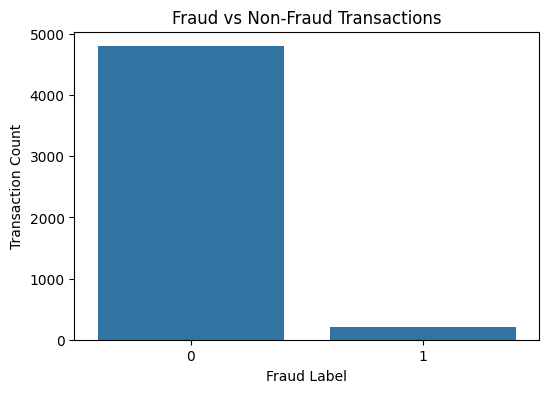

In [207]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='fraud_label',
    data=merged_data
)

plt.title('Fraud vs Non-Fraud Transactions')

plt.xlabel('Fraud Label')

plt.ylabel('Transaction Count')

plt.show()

## Fraud Class Imbalance Interpretation

The dataset demonstrates significant class imbalance, which is common in real-world fraud detection systems where fraudulent transactions represent a relatively small proportion of total transaction volume.

This creates several operational challenges:
- fraudulent activity may be overlooked,
- excessive false positives may increase investigator workload,
- and fraud detection thresholds must balance fraud recall with operational efficiency.

Because of this imbalance, fraud analytics systems require:
- threshold tuning,
- explainable prioritisation logic,
- and investigator-focused triage strategies.

This project therefore focuses not only on fraud prediction accuracy, but also on operational fraud prioritisation and explainable alert management.

# Fraud Rate by Transaction Channel

This visualization compares fraud exposure across transaction channels.

Channel-level fraud analysis helps identify:
- operationally vulnerable channels,
- elevated digital fraud exposure,
- and transaction environments requiring enhanced monitoring.

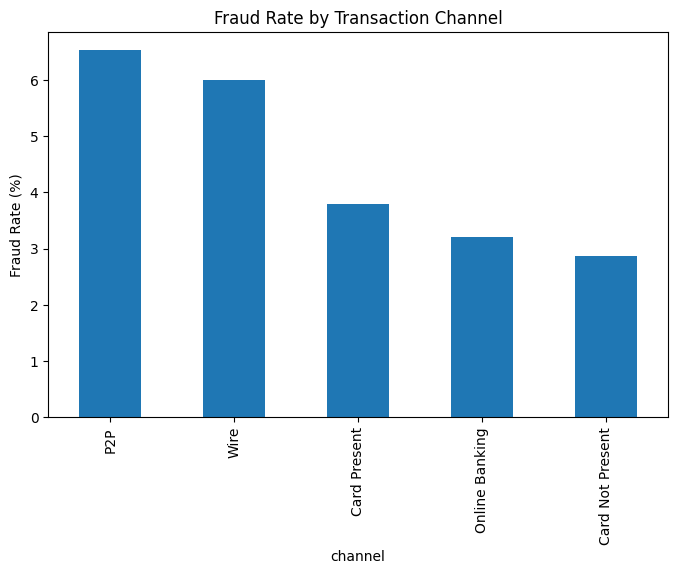

In [208]:
channel_fraud = (
    merged_data
    .groupby('channel')['fraud_label']
    .mean()
    .sort_values(ascending=False) * 100
)

plt.figure(figsize=(8,5))

channel_fraud.plot(kind='bar')

plt.title('Fraud Rate by Transaction Channel')

plt.ylabel('Fraud Rate (%)')

plt.show()

# Fraud Rate by Merchant Category

This visualization highlights merchant categories associated with elevated fraud exposure.

Merchant ecosystem analysis helps identify:
- high-risk industries,
- fraud concentration environments,
- and operational monitoring priorities.

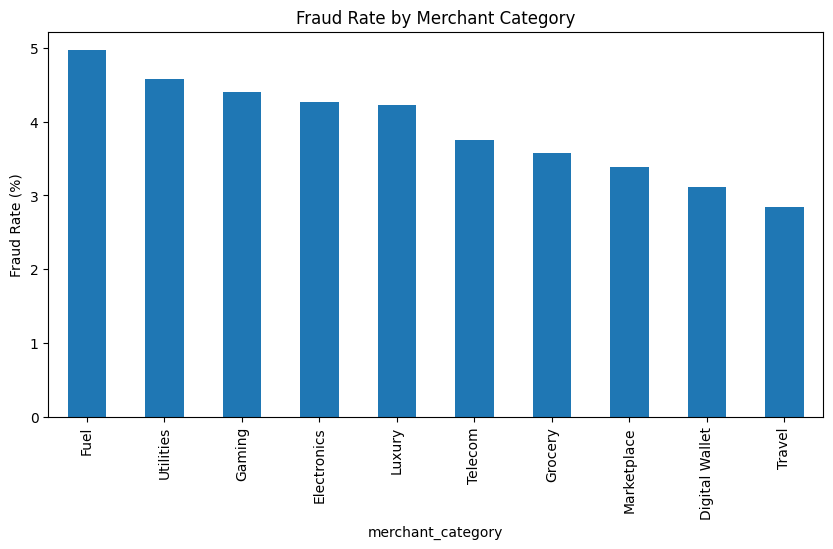

In [209]:
merchant_fraud = (
    merged_data
    .groupby('merchant_category')['fraud_label']
    .mean()
    .sort_values(ascending=False) * 100
)

plt.figure(figsize=(10,5))

merchant_fraud.plot(kind='bar')

plt.title('Fraud Rate by Merchant Category')

plt.ylabel('Fraud Rate (%)')

plt.show()

# Fraud Rate by Risk Category

This visualization evaluates the effectiveness of the explainable fraud intelligence framework.

An effective operational fraud framework should demonstrate:
- increasing fraud concentration across higher risk categories,
- and meaningful separation between low-risk and high-risk transactions.

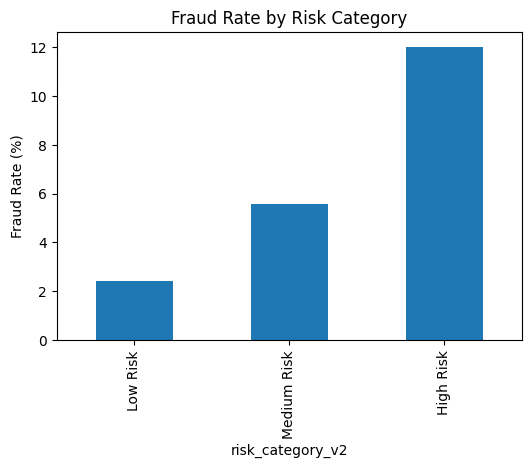

In [210]:
risk_performance = (
    merged_data
    .groupby('risk_category_v2')['fraud_label']
    .mean() * 100
)

plt.figure(figsize=(6,4))

risk_performance.plot(kind='bar')

plt.title('Fraud Rate by Risk Category')

plt.ylabel('Fraud Rate (%)')

plt.show()

# Risk Score Distribution

This visualization shows the distribution of explainable fraud intelligence scores across all transactions.

Risk score distributions help evaluate:
- transaction concentration,
- score spread,
- and operational alert segmentation behavior.

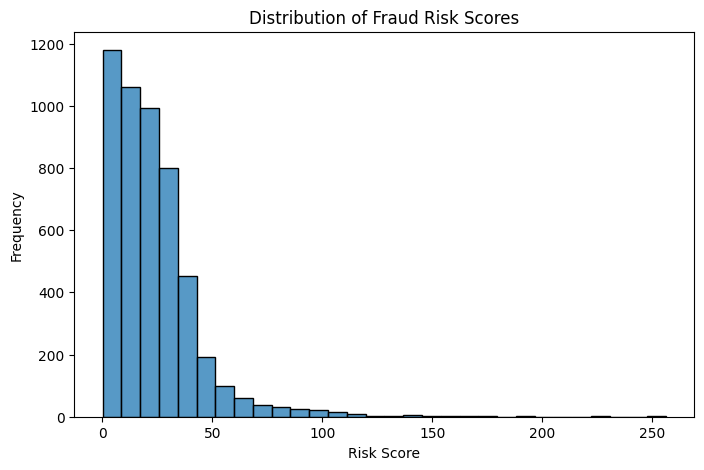

In [211]:
plt.figure(figsize=(8,5))

sns.histplot(
    merged_data['risk_score_v2'],
    bins=30
)

plt.title('Distribution of Fraud Risk Scores')

plt.xlabel('Risk Score')

plt.ylabel('Frequency')

plt.show()

# Exporting Enriched Analytical Dataset

This step exports the enriched fraud intelligence dataset for dashboard development and visualization in Power BI.

The exported dataset includes:
- transaction intelligence,
- customer attributes,
- merchant information,
- fraud labels,
- and explainable risk scores.

This dataset serves as the foundation for executive fraud monitoring dashboards.

In [212]:
merged_data.to_csv(
    '../../B_Dataset/processed/fraud_intelligence_dataset.csv',
    index=False
)

# Assumptions and Operational Limitations

This project was developed using a synthetic banking transaction environment designed to simulate fraud detection and operational alert-prioritisation workflows.

Several assumptions and operational limitations should therefore be considered when interpreting the results.

## Key Assumptions
- Fraud-risk scores generated through the selected Logistic Regression model are treated as operational fraud-risk indicators. XGBoost is retained only as a benchmark and SHAP explainability demonstration.
- Alert thresholds were selected to demonstrate operational tradeoffs between fraud recall, precision, and investigator workload.
- Investigation queues are simulated using threshold-based alert escalation logic.
- Behavioral fraud indicators and customer-risk features are simplified representations of realistic banking fraud environments.
- Operational KPIs are designed to simulate fraud operations management rather than live banking performance metrics.

## Operational Limitations
- The dataset is synthetic and does not represent live banking production systems.
- Fraud behavior patterns may not fully capture evolving real-world fraud tactics.
- Threshold calibration was not optimized using real financial loss exposure or investigation cost modelling.
- Service-level agreement monitoring and investigator staffing simulations were not fully implemented.
- Human investigator judgment remains essential for complex fraud investigation workflows.
- SLA prioritisation, recommended actions, and investigation queues are simplified operational simulations and do not reflect institution-specific fraud operations policies.

## Prototype Positioning
The outputs of this project should therefore be interpreted as operational fraud analytics prototypes designed for educational and workflow simulation purposes rather than live production fraud decisions.

# Business Recommendations and Operational Actions

The operational KPI analysis indicates that the current fraud prioritisation framework successfully identifies a portion of high-risk transactions while maintaining a manageable investigation queue size.

However, the KPI results also highlight the operational tradeoffs commonly observed in fraud operations environments.

## Key Operational Observations
- Fraud recall indicates that additional fraud cases may still bypass the current alerting threshold.
- Fraud precision and queue hit rate suggest that investigators may still experience operational overhead from false-positive alerts.
- Alert volume remains operationally manageable for investigator review workflows.
- Average triage scores indicate that the investigation queue is generally concentrated around higher-risk transactions.

## Recommended Operational Actions
- Continuously recalibrate fraud thresholds to balance fraud coverage against investigator workload.
- Prioritize high-risk alerts using explainable triage scoring and escalation logic.
- Monitor false-positive trends to reduce unnecessary investigation effort.
- Implement periodic governance reviews to evaluate model performance drift and operational effectiveness.
- Maintain human investigator review for complex fraud scenarios requiring contextual judgment.
- Monitor SLA adherence and queue performance to ensure timely investigation of high-risk alerts.

## Leadership Recommendation
Leadership teams should focus on building an explainable and operationally scalable fraud review framework rather than maximising fraud detection volume alone.

The results demonstrate that fraud operations benefit from risk-based alert prioritisation, SLA-driven investigation workflows, and transaction-level explainability through reason codes and recommended actions.

Future improvements should focus on continuous threshold optimisation, operational KPI monitoring, investigator feedback integration, and governance oversight to ensure that fraud detection effectiveness remains aligned with investigation capacity and business risk appetite.

# Project Conclusion

This project developed an explainable fraud intelligence framework that combines machine learning, behavioural analytics, operational dashboards and explainable AI to support fraud alert prioritisation.

The analysis demonstrated that fraud risk is not distributed evenly across transactions. Higher fraud concentrations were consistently observed within specific behavioural, transactional and operational characteristics, enabling investigators to prioritise resources towards higher-value alerts.

Following comparative evaluation, Logistic Regression was selected as the preferred operational model because it provided the strongest balance between fraud detection capability, explainability, operational transparency and business suitability for investigator-led fraud prioritisation.

The developed Power BI dashboards transform analytical outputs into operational decision support by enabling fraud teams to monitor risk distribution, investigation queues, alert quality, detection coverage and operational effectiveness from a single control tower view.

Model governance was strengthened through leakage prevention, SHAP explainability, cross-validation, threshold governance and human-in-the-loop review, ensuring that model outputs remain transparent, interpretable and operationally accountable.

Overall, the proposed framework demonstrates how explainable machine learning can improve fraud investigation prioritisation while supporting responsible AI principles, governance controls and evidence-based operational decision-making.

## Future Enhancements

This project demonstrates an explainable fraud intelligence framework developed using a representative synthetic banking dataset. The methodology, governance approach and operational workflow are designed to be transferable to real-world fraud operations, subject to production validation and deployment.

Future enhancements may include:

- Deployment as an enterprise web-based Fraud Operations Control Tower.
- Real-time transaction scoring through streaming data integration.
- Automated model monitoring, performance tracking and drift detection.
- Investigator feedback loops to continuously refine fraud detection performance.
- Integration with enterprise case management systems and operational workflows.
- Secure cloud deployment to support collaboration, scalability and enterprise-wide monitoring.

These enhancements would further operationalise the framework, enabling explainable, governance-driven and scalable fraud intelligence capabilities within enterprise financial institutions.